In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import LFR
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.adversarial import AdversarialFairnessClassifier
from imblearn.over_sampling import SMOTE

In [43]:
df = pd.read_csv("df.csv")
df_nosens = pd.read_csv("df_nosens.csv")

In [44]:
df.head()

,los,gender,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91,race_ASIAN,race_BLACK,race_EUROPEAN,...,lab_max_51006_missing,lab_max_51221_missing,lab_max_51222_missing,lab_max_51265_missing,lab_count_50912_missing,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality
0,0.410266,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,1,0,0,1,1,1,0
1,3.893252,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.497535,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,1,1,1,1,1,1,1,0
3,1.118032,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.948113,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


### Losgistic Regression
Baseline Model — Without sensitive features  
Full Model — With sensitive features  
Fair Model (Mitigated) — With sensitive features + debiasing  

#### Baseline Model
Reference:  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  

In [45]:
X = df_nosens.drop(columns=['icu_mortality'])
y = df_nosens['icu_mortality']

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(X, y, test_size=0.2, stratify=y, random_state=35)

scaler = StandardScaler()
X_train_baseline_scaled = scaler.fit_transform(X_train_baseline)
X_test_baseline_scaled = scaler.transform(X_test_baseline)


lr_baseline = LogisticRegression(max_iter=5000, random_state=35)
lr_baseline.fit(X_train_baseline_scaled, y_train_baseline)


y_pred_baseline = lr_baseline.predict(X_test_baseline_scaled)
y_proba_baseline = lr_baseline.predict_proba(X_test_baseline_scaled)[:, 1]

print("=== Baseline Model (No Sensitive Features) ===")
print(classification_report(y_test_baseline, y_pred_baseline))
print("AUC:", roc_auc_score(y_test_baseline, y_proba_baseline))

=== Baseline Model (No Sensitive Features) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     17339
           1       0.82      0.49      0.62      1550

    accuracy                           0.95     18889
   macro avg       0.89      0.74      0.79     18889
weighted avg       0.94      0.95      0.94     18889

AUC: 0.9121797402462098


#### Full Model

In [46]:
X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, stratify=y, random_state=35)

scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)

lr_full = LogisticRegression(max_iter=5000, random_state=35)
lr_full.fit(X_train_full_scaled, y_train_full)

y_pred_full = lr_full.predict(X_test_full_scaled)
y_proba_full = lr_full.predict_proba(X_test_full_scaled)[:, 1]

print("=== Full Model (With Sensitive Features) ===")
print(classification_report(y_test_full, y_pred_full))
print("AUC:", roc_auc_score(y_test_full, y_proba_full))

=== Full Model (With Sensitive Features) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     17339
           1       0.82      0.51      0.63      1550

    accuracy                           0.95     18889
   macro avg       0.89      0.75      0.80     18889
weighted avg       0.95      0.95      0.94     18889

AUC: 0.9195618305926041


#### ROC curve for visualizing model performance across all thresholds (true positives vs. false positives trade off)  

AUC doesn’t say your model correctly classifies 92% of cases. It says your model is very good at ranking — i.e., it generally gives higher predicted probabilities to actual positives than to negatives.  

AUC is threshold-independent. AUC = 0.92 means excellent class separation. Your model is very good at assigning higher scores to deaths than to survivors, across all thresholds.  

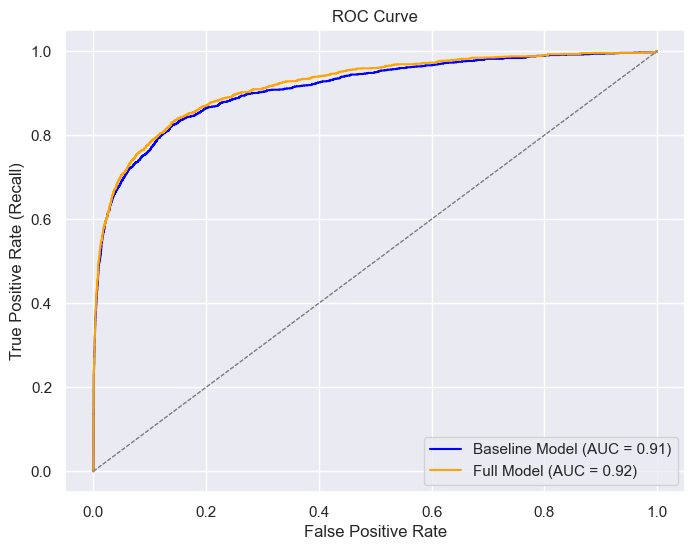

In [47]:
def plot_roc_auc(y_true, y_scores, label='Model', color='blue', ax=None):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC = {auc_score:.2f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curve')
    ax.grid(True)

    return auc_score, ax

fig, ax = plt.subplots(figsize=(8, 6))

auc_baseline, _ = plot_roc_auc(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model',
    color='blue',
    ax=ax
)

auc_full, _ = plot_roc_auc(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model',
    color='orange',
    ax=ax
)

ax.legend()
plt.show()


#### Dataset is imbalanced, so we need to visualize the model to find the best threshold to prioritize recall (detect ICU deaths), but still care about precision (avoid false alarms).


| Term          | What it is                                                   | What it tells you                                                     |
|---------------|--------------------------------------------------------------|------------------------------------------------------------------------|
| **ROC Curve** | A **graph** showing model performance at all thresholds      | Visual: how well the model separates positive and negative classes     |
| **AUC-ROC**   | A **number** between 0 and 1 summarizing the ROC curve       | Score: how well the model ranks positive over negative                 |
| **PR Curve**  | A **graph** of precision vs recall across thresholds         | Helps you **choose a threshold** by optimizing metrics like F1         |  



PR curve for choosing optimal threshold (select the threshold that yields the highest F1)


Baseline Model (No Sens)
Best threshold based on F1 score: 0.327
Precision: 0.720, Recall: 0.590, F1: 0.648

Full Model (With Sens)
Best threshold based on F1 score: 0.356
Precision: 0.743, Recall: 0.579, F1: 0.651


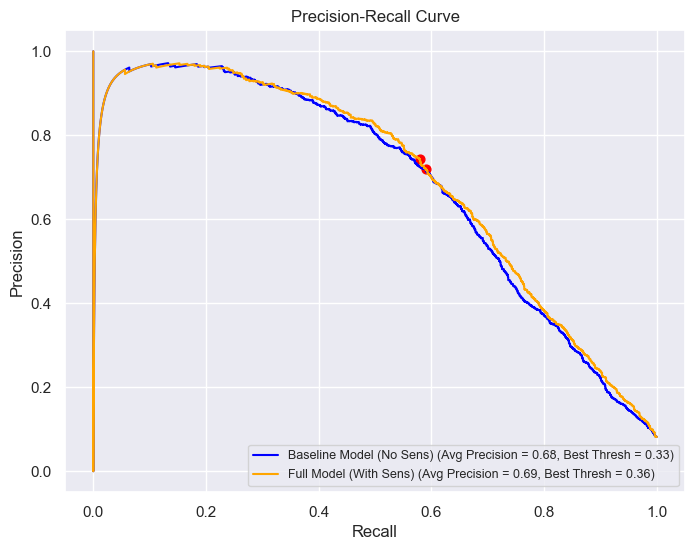

In [48]:
def plot_pr_and_find_best_threshold(y_true, y_scores, label='Model', color='black', ax=None):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    ax.plot(recall, precision, color=color, label=f'{label} (Avg Precision = {ap_score:.2f}, Best Thresh = {best_threshold:.2f})')
    ax.scatter(recall[best_idx], precision[best_idx], color='red', s=40)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve')
    ax.grid(True)

    print(f"\n{label}")
    print(f"Best threshold based on F1 score: {best_threshold:.3f}")
    print(f"Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}, F1: {best_f1:.3f}")

    y_pred = (y_scores >= best_threshold).astype(int)
    return best_threshold, y_pred, auc_score, best_f1, ax

fig, ax = plt.subplots(figsize=(8, 6))

best_thresh_baseline, y_pred_baseline, auc_baseline, best_f1_baseline, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model (No Sens)',
    color='blue',
    ax=ax
)

best_thresh_full, y_pred_full, auc_full, best_f1_full, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model (With Sens)',
    color='orange',
    ax=ax
)


ax.legend(fontsize=9)
plt.show()


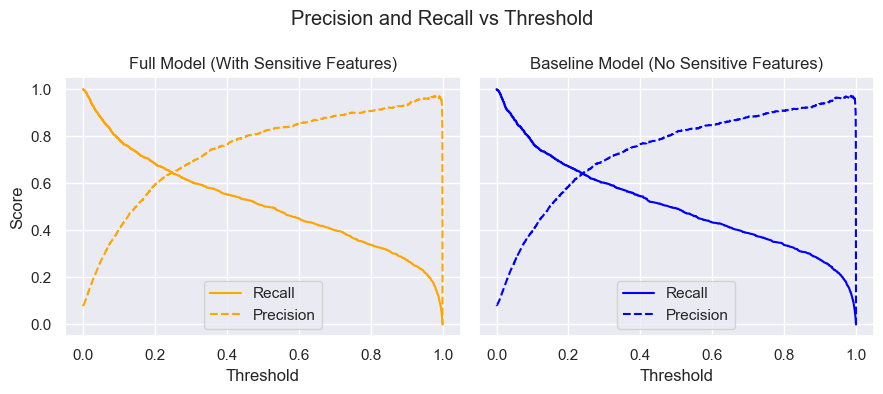

In [49]:
precision_full, recall_full, thresh_full = precision_recall_curve(y_test_baseline, y_proba_full)
precision_baseline, recall_baseline, thresh_baseline = precision_recall_curve(y_test_baseline, y_proba_baseline)


fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey=True)


axs[0].plot(thresh_full, recall_full[:-1], label='Recall', color='orange', linestyle='-')
axs[0].plot(thresh_full, precision_full[:-1], label='Precision', color='orange', linestyle='--')
axs[0].set_title('Full Model (With Sensitive Features)')
axs[0].set_xlabel('Threshold')
axs[0].set_ylabel('Score')
axs[0].legend()
axs[0].grid(True)


axs[1].plot(thresh_baseline, recall_baseline[:-1], label='Recall', color='blue', linestyle='-')
axs[1].plot(thresh_baseline, precision_baseline[:-1], label='Precision', color='blue', linestyle='--')
axs[1].set_title('Baseline Model (No Sensitive Features)')
axs[1].set_xlabel('Threshold')
axs[1].legend()
axs[1].grid(True)

plt.suptitle('Precision and Recall vs Threshold')
plt.tight_layout()
plt.show()


#### Finalize the Full model and Baseline model
- Find the optimal threshold that gives the best F1 score

Baseline Model (No Sensitive Features)
              precision    recall  f1-score   support

           0      0.964     0.979     0.972     17339
           1      0.720     0.590     0.648      1550

    accuracy                          0.947     18889
   macro avg      0.842     0.785     0.810     18889
weighted avg      0.944     0.947     0.945     18889


AUC: 0.912

Full Model (With Sensitive Features)
              precision    recall  f1-score   support

           0      0.963     0.982     0.973     17339
           1      0.743     0.579     0.651      1550

    accuracy                          0.949     18889
   macro avg      0.853     0.781     0.812     18889
weighted avg      0.945     0.949     0.946     18889

AUC: 0.920


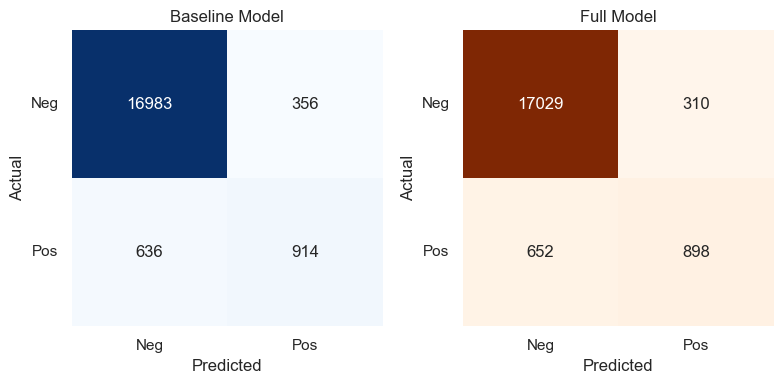

In [50]:
print("Baseline Model (No Sensitive Features)")
print(classification_report(y_test_baseline, y_pred_baseline, digits=3))
print(f"\nAUC: {auc_baseline:.3f}")

print("\nFull Model (With Sensitive Features)")
print(classification_report(y_test_full, y_pred_full, digits=3))
print(f"AUC: {auc_full:.3f}")


cm_baseline = confusion_matrix(y_test_baseline, y_pred_baseline)
cm_full = confusion_matrix(y_test_full, y_pred_full)


fig, axs = plt.subplots(1, 2, figsize=(8, 4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axs[0])
axs[0].set_title('Baseline Model')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].set_xticklabels(['Neg', 'Pos'])
axs[0].set_yticklabels(['Neg', 'Pos'], rotation=0)


sns.heatmap(cm_full, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axs[1])
axs[1].set_title('Full Model')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].set_xticklabels(['Neg', 'Pos'])
axs[1].set_yticklabels(['Neg', 'Pos'], rotation=0)

plt.tight_layout()
plt.show()


### Fairness Diagnosis

Reference:  
https://afraenkel.github.io/fairness-book/content/05-parity-measures.html  
- Equal Opportunity – TPR (Recall)
- Statistical Parity – PPR
- Equalized Odds – TPR, FPR
- Calibration – Predicted probabilities

| **Fairness Metric**      | **What It Measures**                                              | **Key Components**                  |
|--------------------------|-------------------------------------------------------------------|-------------------------------------|
| **Equal Opportunity**    | Equal ability to correctly identify positive cases               | **TPR (Recall)**                    |
| **Statistical Parity**   | Equal likelihood of receiving a positive prediction              | **PPR (Positive Prediction Rate)**  |
| **Equalized Odds**       | Equal error rates across groups                                  | **TPR** and **FPR**                 |
| **Calibration**          | Predicted probabilities reflect actual outcomes per group        | P(Y=1 \| P^=p,A=a)≈p                |

In [51]:
def create_df_test(df, X_test, y_true, y_pred, y_score):
    df_test = df.loc[X_test.index].copy()
    df_test['y_true'] = y_true
    df_test['y_pred'] = y_pred
    df_test['y_score'] = y_score.clip(0, 1)

    gender_map = {1: 'Male', 0: 'Female'}
    age_cols = ['age_18-29', 'age_30-49', 'age_50-64', 'age_65-79', 'age_80-91']
    race_cols = ['race_ASIAN', 'race_BLACK', 'race_EUROPEAN', 'race_HISPANIC/LATINO',
                'race_OTHER', 'race_RUSSIAN', 'race_UNKNOWN', 'race_WHITE']
    
    df_test['gender_group'] = df_test['gender'].map(gender_map)
    df_test['age_group'] = df_test[age_cols].idxmax(axis=1).str.replace('age_', '')
    df_test['race_group'] = df_test[race_cols].idxmax(axis=1).str.replace('race_', '')

    return df_test

df_test_full = create_df_test(df, X_test_full, y_test_full, y_pred_full, y_proba_full)
df_test_baseline = create_df_test(df, X_test_baseline, y_test_baseline, y_pred_baseline, y_proba_baseline)


def get_group_metrics(df_subset, group_col):
    metrics_list = []
    for group in df_subset[group_col].unique():
        group_df = df_subset[df_subset[group_col] == group]
        report = classification_report(
            group_df['y_true'], group_df['y_pred'],
            output_dict=True, zero_division=0
        )
        tn, fp, fn, tp = confusion_matrix(group_df['y_true'], group_df['y_pred']).ravel()
        metrics_list.append({
            'group': group,
            'support': report['1']['support'],
            'precision': report['1']['precision'],
            'recall (TPR)': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
            'PPR': group_df['y_pred'].mean()
        })
    return pd.DataFrame(metrics_list)

gender_report_full = get_group_metrics(df_test_full, 'gender_group')
age_report_full = get_group_metrics(df_test_full, 'age_group')
race_report_full = get_group_metrics(df_test_full, 'race_group')

gender_report_baseline = get_group_metrics(df_test_baseline, 'gender_group')
age_report_baseline = get_group_metrics(df_test_baseline, 'age_group')
race_report_baseline = get_group_metrics(df_test_baseline, 'race_group')

In [52]:
gender_report_full['model'] = 'Full'
age_report_full['model'] = 'Full'
race_report_full['model'] = 'Full'

gender_report_baseline['model'] = 'Baseline'
age_report_baseline['model'] = 'Baseline'
race_report_baseline['model'] = 'Baseline'

gender_comparison = pd.concat([gender_report_full, gender_report_baseline])
age_comparison = pd.concat([age_report_full, age_report_baseline])
race_comparison = pd.concat([race_report_full, race_report_baseline])

gender_comparison
age_comparison
race_comparison

,group,support,precision,recall (TPR),f1_score,FPR,PPR,model
0,WHITE,867.0,0.763608,0.566321,0.650331,0.013879,0.054404,Full
1,OTHER,61.0,0.773585,0.672131,0.719298,0.015852,0.064792,Full
2,UNKNOWN,329.0,0.742647,0.613982,0.672213,0.037076,0.122688,Full
3,BLACK,141.0,0.666667,0.553191,0.604651,0.020051,0.056088,Full
4,HISPANIC/LATINO,52.0,0.767442,0.634615,0.694737,0.015798,0.062774,Full
5,ASIAN,53.0,0.761905,0.603774,0.673684,0.019342,0.073684,Full
6,EUROPEAN,29.0,0.478261,0.379310,0.423077,0.024691,0.044660,Full
7,RUSSIAN,18.0,0.666667,0.555556,0.606061,0.031056,0.083799,Full
0,WHITE,867.0,0.718271,0.594002,0.650253,0.018444,0.060665,Baseline
1,OTHER,61.0,0.736842,0.688525,0.711864,0.019815,0.069682,Baseline


#### Equal Opportunity
All groups should have equal TPR (recall).

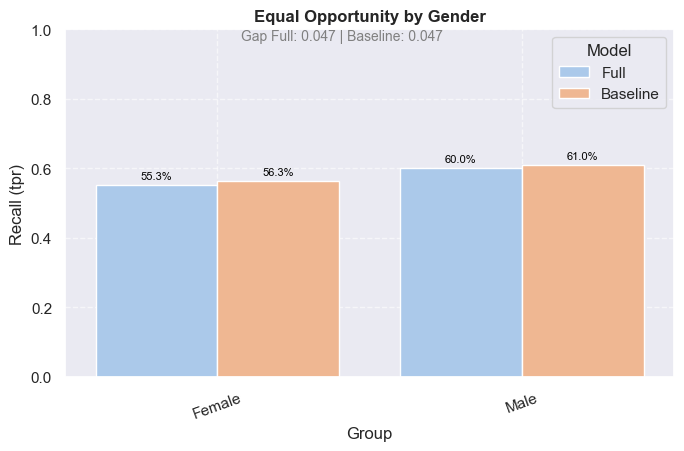

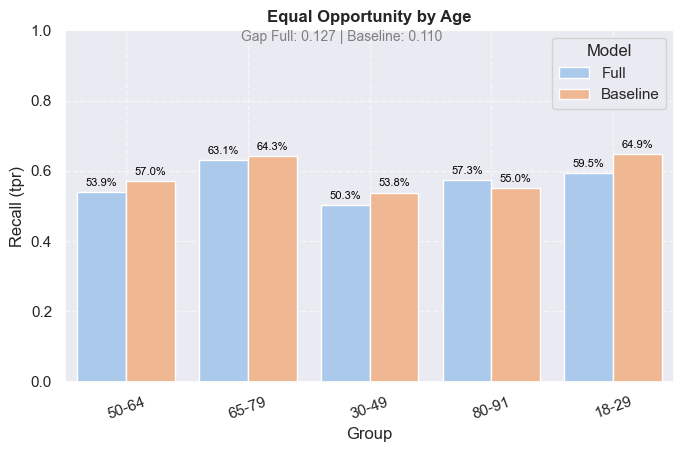

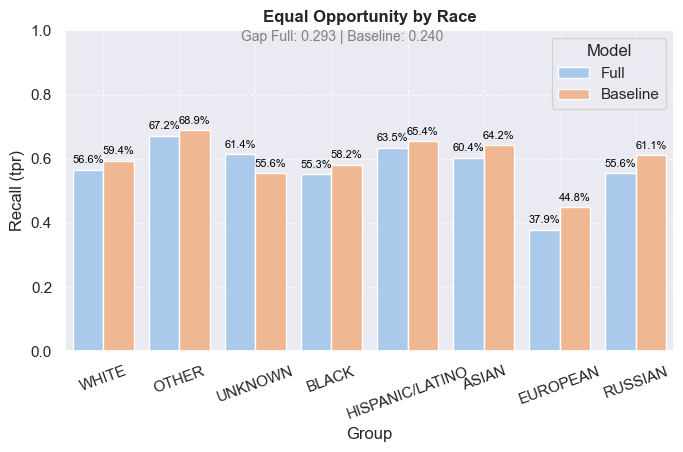

In [53]:
def plot_equal_opportunity(df, metric='recall (TPR)', title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_dict = {}
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df[metric].max() - group_df[metric].min()
        gap_dict[model] = gap
    
    subtitle = "Gap " + " | ".join([f"{model}: {gap:.3f}" for model, gap in gap_dict.items()])

    
    ax = sns.barplot(data=df, x='group', y=metric, hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=8, color='black')

    plt.tight_layout()
    plt.show()

    return gap_dict


eo_gender_dict = plot_equal_opportunity(gender_comparison, metric='recall (TPR)', title='Equal Opportunity by Gender')
eo_age_dict = plot_equal_opportunity(age_comparison, metric='recall (TPR)', title='Equal Opportunity by Age')
eo_race_dict = plot_equal_opportunity(race_comparison, metric='recall (TPR)', title='Equal Opportunity by Race')


#### Positive Prediction Rate by Group (Statistical Parity)

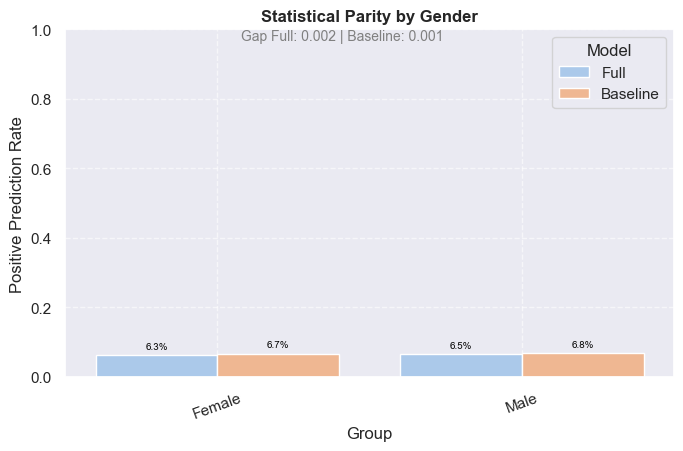

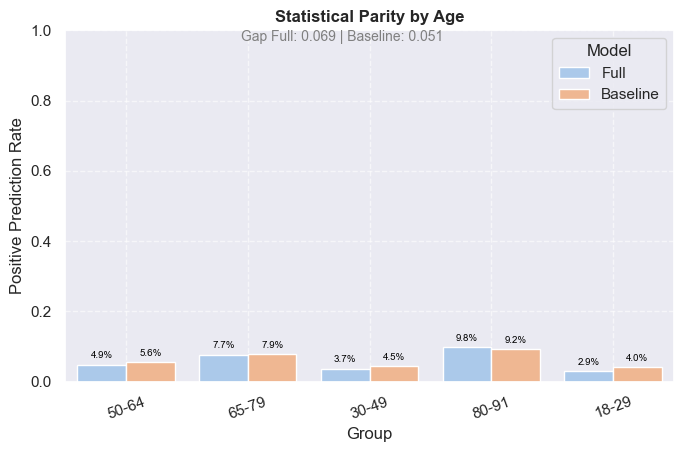

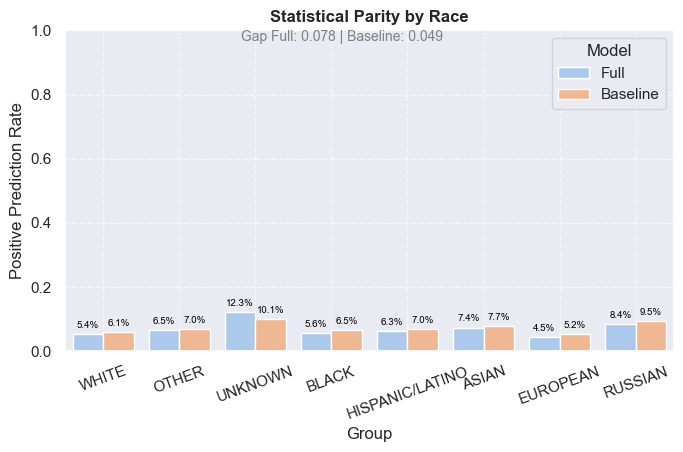

In [54]:

def plot_statistical_parity(df, title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_texts = []
    gap_dict = {}
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df['PPR'].max() - group_df['PPR'].min()
        gap_texts.append(f"{model}: {gap:.3f}")
        gap_dict[model] = gap

    subtitle = "Gap " + " | ".join(gap_texts)


    ax = sns.barplot(data=df, x='group', y='PPR', hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel('Positive Prediction Rate', fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=7, color='black')

    plt.tight_layout()
    plt.show()

    return gap_dict

gender_ppr_dict = plot_statistical_parity(df=gender_comparison, title='Statistical Parity by Gender')
age_ppr_dict = plot_statistical_parity(df=age_comparison, title='Statistical Parity by Age')
race_ppr_dict = plot_statistical_parity(df=race_comparison, title='Statistical Parity by Race')


#### Equaliezed Odds - TPR, FPR

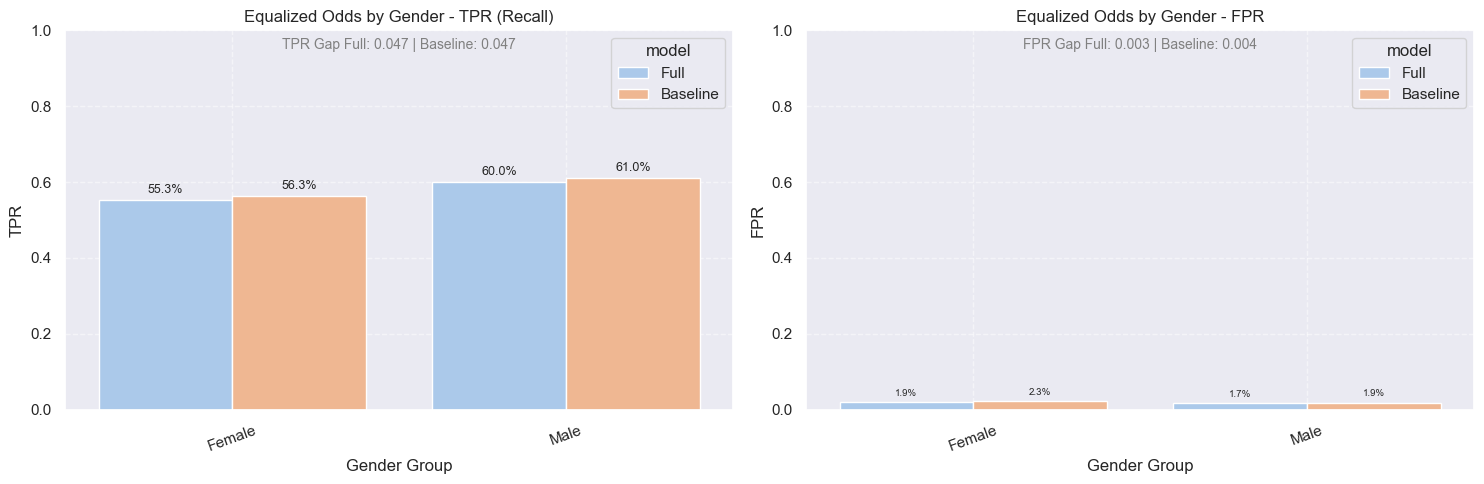

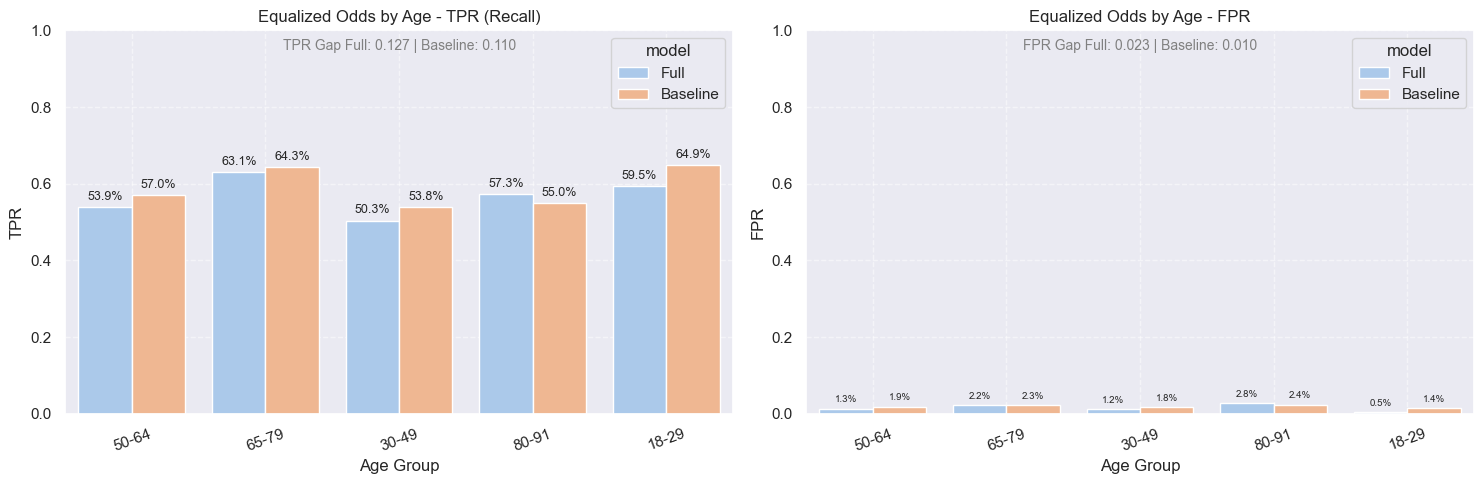

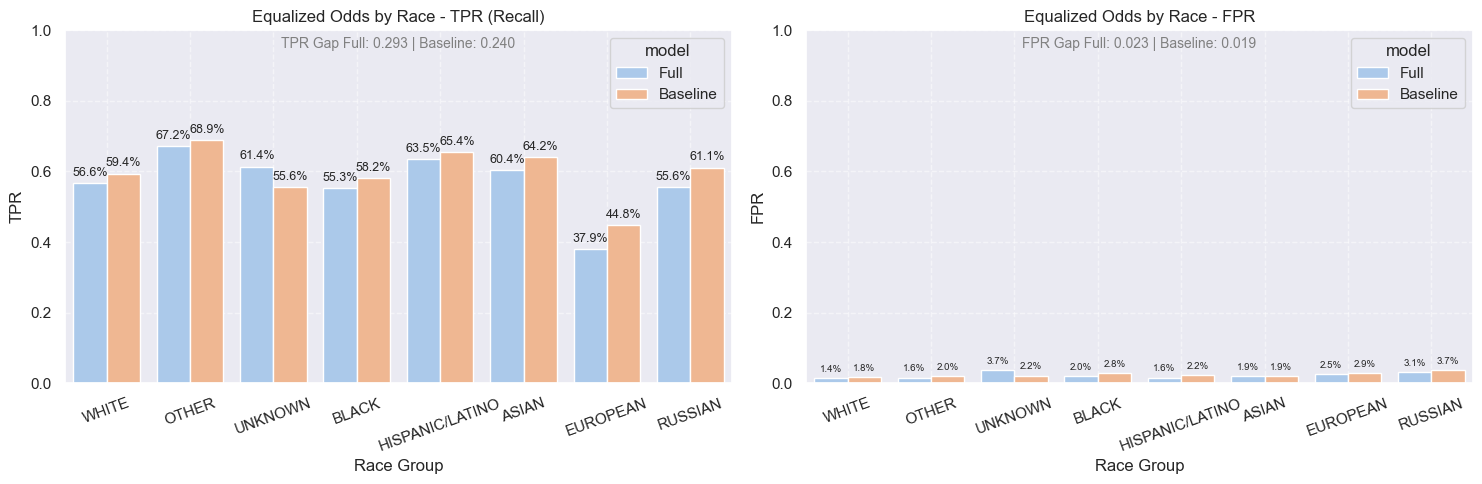

In [55]:
def plot_equalized_odds(df, group_col_name, title_prefix, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # subtitles
    tpr_gap_texts = []
    fpr_gap_texts = []
    tpr_gap_dict = {}
    fpr_gap_dict = {}

    for model in df['model'].unique():
        model_df = df[df['model'] == model]
        tpr_gap = model_df['recall (TPR)'].max() - model_df['recall (TPR)'].min()
        fpr_gap = model_df['FPR'].max() - model_df['FPR'].min()
        tpr_gap_texts.append(f"{model}: {tpr_gap:.3f}")
        fpr_gap_texts.append(f"{model}: {fpr_gap:.3f}")
        tpr_gap_dict[model] = tpr_gap
        fpr_gap_dict[model] = fpr_gap


    axs[0].text(0.5, 0.95, "TPR Gap " + " | ".join(tpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[0].transAxes)

    axs[1].text(0.5, 0.95, "FPR Gap " + " | ".join(fpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[1].transAxes)


    # TPR
    sns.barplot(data=df, x='group', y='recall (TPR)', hue='model', palette='pastel', ax=axs[0])
    axs[0].set_title(f'{title_prefix} - TPR (Recall)', fontsize=12)
    axs[0].set_xlabel(group_col_name)
    axs[0].tick_params(axis='x', rotation=20)
    axs[0].set_ylabel('TPR')
    axs[0].set_ylim(0, 1)
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[0].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[0].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=9)

    # FPR
    sns.barplot(data=df, x='group', y='FPR', hue='model', palette='pastel', ax=axs[1])
    axs[1].set_title(f'{title_prefix} - FPR', fontsize=12)
    axs[1].set_xlabel(group_col_name)
    axs[1].tick_params(axis='x', rotation=20)
    axs[1].set_ylabel('FPR')
    axs[1].set_ylim(0, 1)
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[1].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[1].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.show()

    return tpr_gap_dict, fpr_gap_dict

gender_tpr_dict, gender_fpr_dict = plot_equalized_odds(gender_comparison, group_col_name='Gender Group', title_prefix='Equalized Odds by Gender')
age_tpr_dict, age_fpr_dict = plot_equalized_odds(age_comparison, group_col_name='Age Group', title_prefix='Equalized Odds by Age')
race_tpr_dict, race_fpr_dict = plot_equalized_odds(race_comparison, group_col_name='Race Group', title_prefix='Equalized Odds by Race')

#### Calibration - The predicted probability reflects reality
x-axis	Mean predicted probability in each bin → average of y_score  
y-axis	Actual observed frequency → proportion of y_true == 1 in the bin  

The Expected Calibration Error (ECE) is defined as:

$$
\text{ECE} = \sum_{b=1}^{B} \frac{n_b}{n} \left| \text{accuracy}(b) - \text{confidence}(b) \right|
$$
The difference between accuracy and confidence represents the error between reality and expectation. Therefore, a smaller error indicates better calibration.  

Calibration plot = visual relationship between predicted vs. observed probabilities.  
ECE = numeric average of the vertical gaps between points and the perfect diagonal.  


Model could be Unfair but calibrated (larger equal opportunity gap lesser ece) or Fair but uncalibrated.

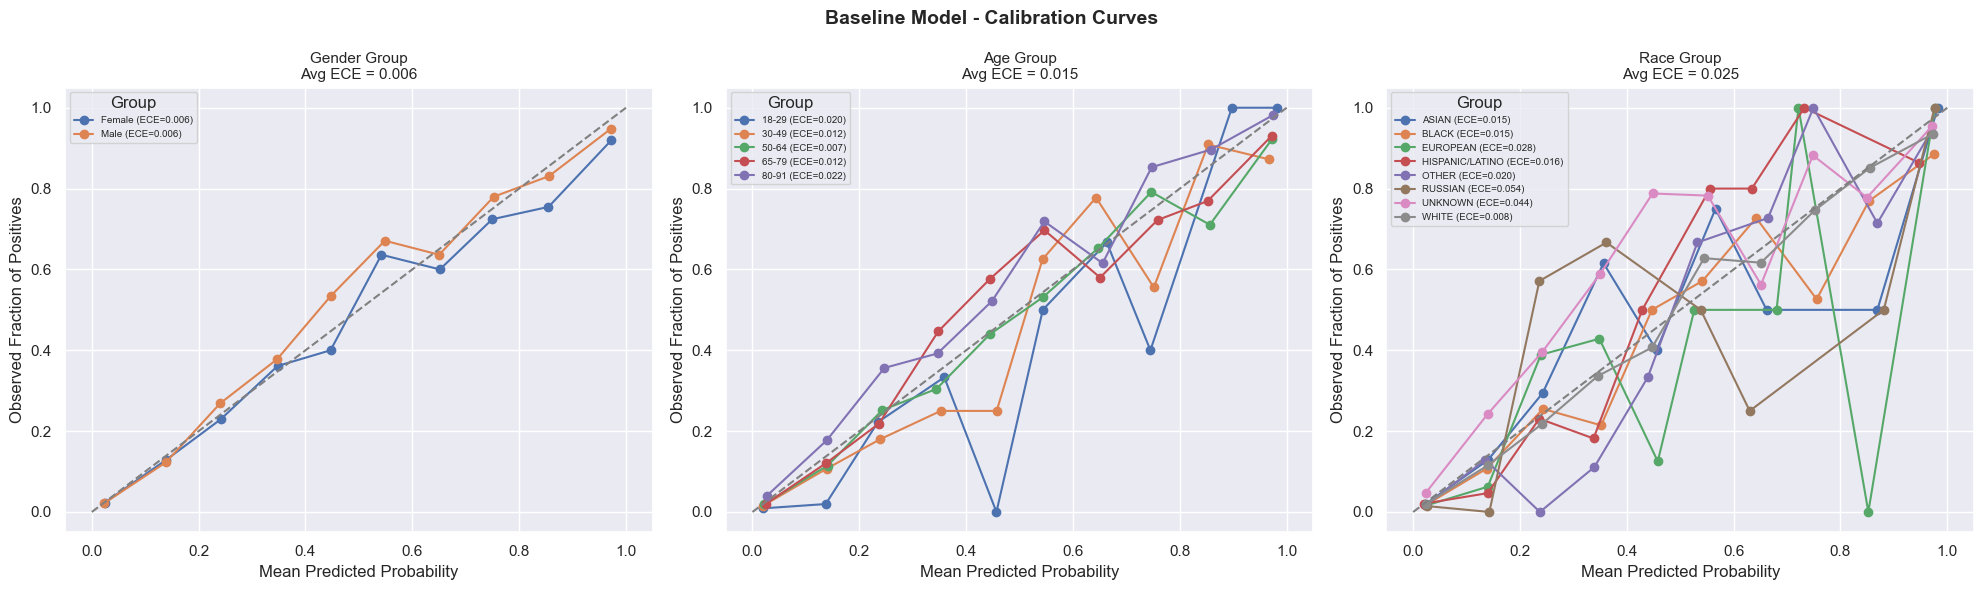

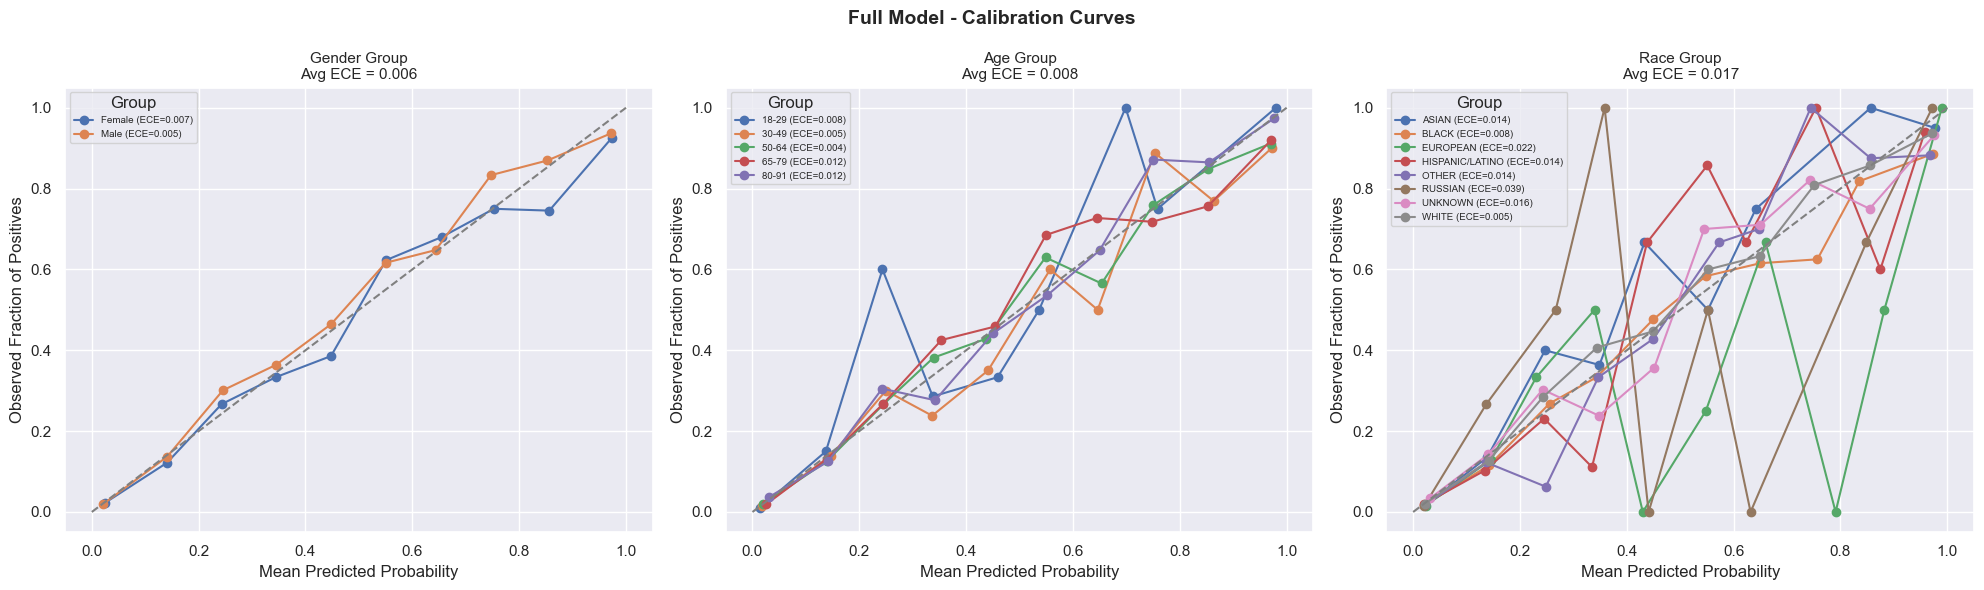

In [56]:
def compute_ece(y_true, y_score, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(y_score, bins) - 1
    ece = 0.0

    for i in range(n_bins):
        mask = bin_indices == i
        if np.any(mask):
            bin_confidence = y_score[mask].mean()
            bin_accuracy = y_true[mask].mean()
            bin_size = mask.sum() / len(y_true)
            ece += bin_size * np.abs(bin_confidence - bin_accuracy)
    
    return ece

def plot_calibration_ece(df, model_label, n_bins=10, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    group_cols = ['gender_group', 'age_group', 'race_group']
    titles = ['Gender Group', 'Age Group', 'Race Group']
    avg_subgroup_ece = {}

    for i, (group_col, title) in enumerate(zip(group_cols, titles)):
        ax = axs[i]
        group_df = df
        subgroups = sorted(group_df[group_col].unique())

        subgroup_ece_list = []
        subgroup_labels = []
        

        for subgroup in subgroups:
            subgroup_df = group_df[group_df[group_col] == subgroup]
            y_true = subgroup_df['y_true']
            y_score = subgroup_df['y_score']
            
            subgroup_ece = compute_ece(y_true, y_score)
            subgroup_ece_list.append(subgroup_ece)
            
            prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy='uniform')
            ax.plot(prob_pred, prob_true, marker='o')
            subgroup_labels.append(f'{subgroup} (ECE={subgroup_ece:.3f})')

        
        avg_subgroup_ece[group_col] = np.mean(subgroup_ece_list)


        ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
        ax.set_xlabel('Mean Predicted Probability')
        ax.set_ylabel('Observed Fraction of Positives')
        ax.set_title(f'{title}\nAvg ECE = {avg_subgroup_ece[group_col]:.3f}', fontsize=11)
        ax.grid(True)
        ax.legend(subgroup_labels, fontsize=7, title='Group')

    plt.suptitle(f'{model_label} Model - Calibration Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return avg_subgroup_ece

df_list = [df_test_baseline, df_test_full]
model_label = ['Baseline', 'Full']
avg_subgroup_ece = {}
for df_l, model_l in zip(df_list, model_label):
    avg_subgroup_ece[model_l] = plot_calibration_ece(df=df_l, model_label = model_l, figsize=(20, 6))


#### Bias Mitigation 1
- apply SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance in the ICU mortality label  
- reweighting  

In [57]:
df_dummy = df.copy()

age_cols = ['age_18-29', 'age_30-49', 'age_50-64',   'age_65-79', 'age_80-91']
race_cols = ['race_ASIAN', 'race_BLACK', 'race_EUROPEAN', 'race_HISPANIC/LATINO',
             'race_OTHER', 'race_RUSSIAN', 'race_UNKNOWN', 'race_WHITE']

df_dummy['age_group'] = df_dummy[age_cols].idxmax(axis=1).str.replace('age_', '')
df_dummy['race_group'] = df_dummy[race_cols].idxmax(axis=1).str.replace('race_', '')
df_dummy['gender_group'] = df_dummy['gender'].map({0: 'Female', 1: 'Male'})

# reweighting intersection group (gender, age, race)
df_dummy['gender_race_age'] = df_dummy[['gender', 'race_group', 'age_group']].astype(str).agg(','.join, axis=1)
group_counts = df_dummy['gender_race_age'].value_counts()
group_weights = 1 / group_counts
group_weights = group_weights / group_weights.sum()
df_dummy['group_weight'] = df_dummy['gender_race_age'].map(group_weights) 
df_dummy

,los,gender,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91,race_ASIAN,race_BLACK,race_EUROPEAN,...,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality,age_group,race_group,gender_group,gender_race_age,group_weight
0,0.410266,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,1,0,50-64,WHITE,Female,"0,WHITE,50-64",0.000088
1,3.893252,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,80-91,WHITE,Female,"0,WHITE,80-91",0.000106
2,0.497535,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,1,1,0,65-79,BLACK,Female,"0,BLACK,65-79",0.000369
3,1.118032,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,50-64,WHITE,Female,"0,WHITE,50-64",0.000088
4,0.948113,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,50-64,WHITE,Female,"0,WHITE,50-64",0.000088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94439,6.950370,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,30-49,WHITE,Male,"1,WHITE,30-49",0.000146
94440,0.960741,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,80-91,WHITE,Male,"1,WHITE,80-91",0.000114
94441,1.790995,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,30-49,WHITE,Female,"0,WHITE,30-49",0.000188
94442,5.297766,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,50-64,WHITE,Male,"1,WHITE,50-64",0.000057


In [58]:
X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']
sample_weight = df_dummy['group_weight']

X_train_bm1, X_test_bm1, y_train_bm1, y_test_bm1, w_train_bm1, w_test_bm1 = train_test_split(X, y, sample_weight, test_size=0.2, stratify=y, random_state=35)

scaler = StandardScaler()
X_train_bm1_scaled = scaler.fit_transform(X_train_bm1)
X_test_bm1_scaled = scaler.transform(X_test_bm1)

# ----------------------------------------------- manually smote ----------------------------------------------
X_train_bm1_df = pd.DataFrame(X_train_bm1_scaled)
X_train_bm1_df['y'] = y_train_bm1.reset_index(drop=True)
X_train_bm1_df['weight'] = w_train_bm1.reset_index(drop=True)

pos = X_train_bm1_df[X_train_bm1_df['y'] == 1]
neg = X_train_bm1_df[X_train_bm1_df['y'] == 0]

# upsample, shuffle and combine
pos_upsampled = pos.sample(n=len(neg), replace=True, random_state=35)
smote = pd.concat([neg, pos_upsampled], axis=0).sample(frac=1, random_state=35).reset_index(drop=True)

X_train_bm1_smote = smote.drop(columns=['y', 'weight']).values
y_train_bm1_smote = smote['y'].values
w_train_bm1_smote = smote['weight'].values

lr = LogisticRegression(max_iter=1000, random_state=35)
lr.fit(X_train_bm1_smote, y_train_bm1_smote, sample_weight=w_train_bm1_smote)

y_pred_bm1 = lr.predict(X_test_bm1_scaled)
y_proba_bm1 = lr.predict_proba(X_test_bm1_scaled)[:, 1]

print("=== Bias Mitigation 1 - SMOTE + Reweighting ===")
print(classification_report(y_test_bm1, y_pred_bm1))
print("AUC:", roc_auc_score(y_test_bm1, y_proba_bm1))


=== Bias Mitigation 1 - SMOTE + Reweighting ===
              precision    recall  f1-score   support

           0       0.98      0.84      0.91     17339
           1       0.31      0.79      0.45      1550

    accuracy                           0.84     18889
   macro avg       0.64      0.82      0.68     18889
weighted avg       0.92      0.84      0.87     18889

AUC: 0.897650532363179


#### Bias Mitigation 2 ( multiple attempts failed! skip LFR)
- SMOTE + Fair Representation

Reference:  
https://infomdwr.nl/labs/week_9/3_Fairness/3_Fairness_answers_6781.html?utm_source=chatgpt.com  
https://aif360.readthedocs.io/en/stable/modules/generated/aif360.algorithms.preprocessing.LFR.html#aif360.algorithms.preprocessing.LFR  
https://aif360.readthedocs.io/en/stable/modules/generated/aif360.datasets.BinaryLabelDataset.html#aif360-datasets-binarylabeldataset  


In [59]:
X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
sens = df_dummy['gender_race_age']


X_train_bm2, X_test_bm2, y_train_bm2, y_test_bm2, s_train_bm2, s_test_bm2 = train_test_split(
    X, y, sens, test_size=0.2, stratify=y, random_state=35
)

scaler = StandardScaler()
X_train_bm2_scaled = scaler.fit_transform(X_train_bm2)
X_test_bm2_scaled = scaler.transform(X_test_bm2)

le = LabelEncoder()
s_train_bm2_encoded = le.fit_transform(s_train_bm2)
s_test_bm2_encoded = le.transform(s_test_bm2)

encoding_map = {index: label for index, label in enumerate(le.classes_)}
print("Encoding Map:")
for k, v in encoding_map.items():
    print(f"{k} -> {v}")

'''
After SMOTE upsamples X and y from the minority group, we obtain a new set of synchronized instances.
We preserve the original sensitive attributes for existing data, and approximate the sensitive attributes for synthetic samples 
by randomly copying from the original minority class instances. As a result, the final resampled dataset consists of synchronized X and y, 
along with sensitive attributes that are either preserved (for original samples) or approximated (for synthetic ones) 
'''
# Apply SMOTE only to X and y not sensitive attributes
Xys = pd.DataFrame(X_train_bm2_scaled, columns=X.columns)
Xys['icu_mortality'] = y_train_bm2.values
Xys['gender_race_age'] = s_train_bm2_encoded
Xys.reset_index(drop=True, inplace=True)

smote = SMOTE(random_state=35)
X_resampled, y_resampled = smote.fit_resample(
    Xys.drop(columns=['icu_mortality', 'gender_race_age']),
    Xys['icu_mortality']
)

# Assign sensitive attributes by randomly copying from the original minority class instances
n_original = len(Xys)
n_resampled = len(X_resampled)
n_diff = n_resampled - n_original

minority_indices = Xys[Xys['icu_mortality'] == 1].index
new_indices = np.random.choice(minority_indices, size=n_diff, replace=True)

s_resampled = np.concatenate([
    Xys['gender_race_age'].values,
    Xys.loc[new_indices, 'gender_race_age'].values
])

X_train_bm2_smote = X_resampled
y_train_bm2_smote = y_resampled
s_train_bm2_encoded_smote = s_resampled

print("\nTraining size and input features and class distribution:")
print(X_train_bm2_smote.shape)
print(np.unique(y_train_bm2_smote, return_counts=True))

Encoding Map:
0 -> 0,ASIAN,18-29
1 -> 0,ASIAN,30-49
2 -> 0,ASIAN,50-64
3 -> 0,ASIAN,65-79
4 -> 0,ASIAN,80-91
5 -> 0,BLACK,18-29
6 -> 0,BLACK,30-49
7 -> 0,BLACK,50-64
8 -> 0,BLACK,65-79
9 -> 0,BLACK,80-91
10 -> 0,EUROPEAN,18-29
11 -> 0,EUROPEAN,30-49
12 -> 0,EUROPEAN,50-64
13 -> 0,EUROPEAN,65-79
14 -> 0,EUROPEAN,80-91
15 -> 0,HISPANIC/LATINO,18-29
16 -> 0,HISPANIC/LATINO,30-49
17 -> 0,HISPANIC/LATINO,50-64
18 -> 0,HISPANIC/LATINO,65-79
19 -> 0,HISPANIC/LATINO,80-91
20 -> 0,OTHER,18-29
21 -> 0,OTHER,30-49
22 -> 0,OTHER,50-64
23 -> 0,OTHER,65-79
24 -> 0,OTHER,80-91
25 -> 0,RUSSIAN,18-29
26 -> 0,RUSSIAN,30-49
27 -> 0,RUSSIAN,50-64
28 -> 0,RUSSIAN,65-79
29 -> 0,RUSSIAN,80-91
30 -> 0,UNKNOWN,18-29
31 -> 0,UNKNOWN,30-49
32 -> 0,UNKNOWN,50-64
33 -> 0,UNKNOWN,65-79
34 -> 0,UNKNOWN,80-91
35 -> 0,WHITE,18-29
36 -> 0,WHITE,30-49
37 -> 0,WHITE,50-64
38 -> 0,WHITE,65-79
39 -> 0,WHITE,80-91
40 -> 1,ASIAN,18-29
41 -> 1,ASIAN,30-49
42 -> 1,ASIAN,50-64
43 -> 1,ASIAN,65-79
44 -> 1,ASIAN,80-91
45 -> 1,BLA

##### Defining Privileged and Unprivileged Groups Using Equal Opportunity (TPR)

| **Dimension** | **Privileged**                          | **Unprivileged**                 |
|---------------|-----------------------------------------|----------------------------------|
| **Gender**    | Male                                    | Female                           |
| **Age**       | 18–29, 65–79                            | 30–49, 50–64, 80-91              |
| **Race**      | OTHER, ASIAN, HISPANIC/LATINO, UNKNOWN  | EUROPEAN, BLACK, RUSSIAN, WHITE  |


In [60]:
# ----------------------------------------- Learn Fair Representation ----------------------------------------
train_df = pd.concat([pd.DataFrame(X_train_bm2_smote, columns=X.columns), pd.DataFrame({
        'icu_mortality': y_train_bm2_smote.values,
        'gender_race_age': s_train_bm2_encoded_smote.flatten()
    })], axis=1)


train_bld = BinaryLabelDataset(
    favorable_label=0, # survived (negative)
    unfavorable_label=1, # died (positive)
    df=train_df,
    label_names=['icu_mortality'],
    protected_attribute_names=['gender_race_age']
)

test_df = pd.concat([pd.DataFrame(X_test_bm2_scaled, columns=X.columns), pd.DataFrame({
        'icu_mortality': y_test_bm2.values,
        'gender_race_age': s_test_bm2_encoded.flatten()
    })], axis=1)

test_bld = BinaryLabelDataset(
    favorable_label=0,
    unfavorable_label=1,
    df=test_df,
    label_names=['icu_mortality'],
    protected_attribute_names=['gender_race_age']
)


unprivileged_groups = {}
privileged_groups = {}

for idx, label in encoding_map.items():
    gender, race, age = label.split(',')

    # Define TPR-based group membership
    if (
        gender == '0' and age in ['30-49', '50-64', '80-91'] and race in ['EUROPEAN', 'BLACK', 'UNKNOWN', 'WHITE']):
        unprivileged_groups[label] = idx
    else:
        privileged_groups[label] = idx


# explore the unprivileged and privileged groups that contain the most samples to train LFR
for idx, label in encoding_map.items():
    group_df = train_df[train_df['gender_race_age'] == idx]
    total = len(group_df)
    class_counts = group_df['icu_mortality'].value_counts()

    if total >= 4000 and len(class_counts) > 1:
        print(f"Group {idx} ({label}):")
        print('Unprivileged Group' if label in unprivileged_groups.keys() else "Privileged group")
        print(class_counts)
        print('-' * 40)


Group 37 (0,WHITE,50-64):
Unprivileged Group
icu_mortality
0    5250
1    3785
Name: count, dtype: int64
----------------------------------------
Group 38 (0,WHITE,65-79):
Privileged group
icu_mortality
1    6434
0    6227
Name: count, dtype: int64
----------------------------------------
Group 39 (0,WHITE,80-91):
Unprivileged Group
icu_mortality
1    5310
0    4190
Name: count, dtype: int64
----------------------------------------
Group 73 (1,UNKNOWN,65-79):
Privileged group
icu_mortality
1    2691
0    1454
Name: count, dtype: int64
----------------------------------------
Group 76 (1,WHITE,30-49):
Privileged group
icu_mortality
0    3198
1    1666
Name: count, dtype: int64
----------------------------------------
Group 77 (1,WHITE,50-64):
Privileged group
icu_mortality
0    8139
1    6023
Name: count, dtype: int64
----------------------------------------
Group 78 (1,WHITE,65-79):
Privileged group
icu_mortality
0    8696
1    8387
Name: count, dtype: int64
---------------------------

k [5–20]  
Number of prototypes used to represent each group. Larger k gives more expressive power but increases model complexity and training time.

Ax [0.001–1.0]  
Higher Ax → strongly penalized for deviating from the input → the learned representation stays very close to the original input.

Ay [1.0–50.0]  
Higher Ay → emphasizes prediction accuracy. Useful when fairness is secondary.

AZ [0.001–1.0]  
Higher Az → stronger push toward fair representation (i.e., less information about sensitive attributes).

In [61]:
''' 
LFR only supports exactly one unprivileged and privileged group. 
Hence, we need to select one of the groups from unprivileged_groups and privileged_groups.
In this case, we will select {73: '1,UNKNOWN,65-79'} as the privileged group while {39 -> 0,WHITE,80-91} as the unprivileged group.
'''

lfr = LFR(
    unprivileged_groups=[{'gender_race_age': 39}],
    privileged_groups=[{'gender_race_age': 73}],
    k=5,
    Ax=0.5,   # Let it distort features significantly
    Ay=0.5,   # Weaken label memory
    Az=20.0,  # Very strong fairness signal
    verbose=0
)


lfr.fit(train_bld)

train_transf = lfr.transform(train_bld)
test_transf = lfr.transform(test_bld)

# Check the distribution of the labels before/after transformed
print(np.unique(train_bld.labels, return_counts=True))
print(np.unique(test_bld.labels, return_counts=True))
print(np.unique(train_transf.labels, return_counts=True))
print(np.unique(test_transf.labels, return_counts=True))

# ----------------------------------- Train logistic regression on fair representation ----------------------------------
X_train_lfr = train_transf.features
y_train_lfr = train_transf.labels.ravel()

X_test_lfr = test_transf.features
y_test_lfr = test_transf.labels.ravel()

print("\nTraining size and input features:")
print(X_train_lfr.shape)
print(np.unique(y_train_lfr, return_counts=True))

lr = LogisticRegression(max_iter=3000, random_state=35)
lr.fit(X_train_lfr, y_train_lfr)


y_pred_lfr = lr.predict(X_test_lfr)
y_proba_lfr = lr.predict_proba(X_test_lfr)[:, 1]


print("=== Bias Mitigation 2 - SMOTE + Fair Representation (LFR) ===")
print(classification_report(y_test_lfr, y_pred_lfr))
print("AUC:", roc_auc_score(y_test_lfr, y_proba_lfr))

(array([0., 1.]), array([69353, 69353]))
(array([0., 1.]), array([17339,  1550]))
(array([0., 1.]), array([125061,  13645]))
(array([0., 1.]), array([17303,  1586]))

Training size and input features:
(138706, 116)
(array([0., 1.]), array([125061,  13645]))
=== Bias Mitigation 2 - SMOTE + Fair Representation (LFR) ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17303
         1.0       1.00      1.00      1.00      1586

    accuracy                           1.00     18889
   macro avg       1.00      1.00      1.00     18889
weighted avg       1.00      1.00      1.00     18889

AUC: 0.9999422065537767


After extensive experimentation with Learning Fair Representations (LFR), testing multiple combinations of parameters (Ax, Ay, Az, and k), we found that LFR consistently overfits the training data by projecting test samples extremely close to training samples in the latent space—effectively causing data leakage through representation. This was evidenced by perfect test performance (accuracy and AUC = 1.0) and a near-zero average minimum distance between transformed train and test points. Despite correct train/test splitting and efforts to enforce fairness, LFR memorized label structures, leading to unrealistic generalization. We conclude that LFR is unsuitable for this dataset and recommend switching to alternative fairness techniques

In [62]:
from sklearn.metrics import pairwise_distances

# Check average distance between train and test points in transformed space
dists = pairwise_distances(train_transf.features, test_transf.features)
print("Average minimum distance from test points to train points:", dists.min(axis=0).mean())


Average minimum distance from test points to train points: 0.0044174180943784966


#### Bias Mitigation 2
- ExponentiatedGradient with regularization  

Source:  
https://fairlearn.org/v0.10/api_reference/generated/fairlearn.reductions.ExponentiatedGradient.html  

In [63]:
X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
sens = df_dummy['race_group']

X_train_bm2, X_test_bm2, y_train_bm2, y_test_bm2, s_train_bm2, s_test_bm2 = train_test_split(
    X, y, sens, test_size=0.2, stratify=y, random_state=35
)

scaler = StandardScaler()
X_train_bm2_scaled = scaler.fit_transform(X_train_bm2)
X_test_bm2_scaled = scaler.transform(X_test_bm2)

# ----------------------------------------------- manually smote ----------------------------------------------
X_train_bm2_df = pd.DataFrame(X_train_bm2_scaled, columns=X.columns)
X_train_bm2_df['y'] = y_train_bm2.reset_index(drop=True)
X_train_bm2_df['race_group'] = s_train_bm2.reset_index(drop=True)

pos = X_train_bm2_df[X_train_bm2_df['y'] == 1]
neg = X_train_bm2_df[X_train_bm2_df['y'] == 0]

# upsample, shuffle and combine
pos_upsampled = pos.sample(n=len(neg), replace=True, random_state=35)
smote = pd.concat([neg, pos_upsampled], axis=0).sample(frac=1, random_state=35).reset_index(drop=True)

X_train_bm2_smote = smote.drop(columns=['y', 'race_group']).values
y_train_bm2_smote = smote['y'].values
s_train_bm2_smote = smote['race_group'].values

lr = LogisticRegression(max_iter=3000, random_state=35)
mitigator = ExponentiatedGradient(
    estimator=lr,
    constraints=EqualizedOdds(),
    eps=0.1
)

mitigator.fit(X_train_bm2_smote, y_train_bm2_smote, sensitive_features=s_train_bm2_smote)

y_pred_bm2 = mitigator.predict(X_test_bm2_scaled)
y_proba_bm2 = mitigator._pmf_predict(X_test_bm2_scaled)[:, 1]

print("=== Bias Mitigation 2 - SMOTE + Regularization ===")
print(classification_report(y_test_bm2, y_pred_bm2))
print("AUC:", roc_auc_score(y_test_bm2, y_proba_bm2))

=== Bias Mitigation 2 - SMOTE + Regularization ===
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     17339
           1       0.36      0.79      0.49      1550

    accuracy                           0.87     18889
   macro avg       0.67      0.83      0.71     18889
weighted avg       0.93      0.87      0.89     18889

AUC: 0.8852247497251209


#### Bias Mitigation 3  
Reference:  
https://fairlearn.org/v0.9/api_reference/generated/fairlearn.adversarial.AdversarialFairnessClassifier.html  
Notes:  
fairlearn.adversarial.AdversarialFairnessClassifier, it expects numpy arrays (no manual TensorFlow conversion needed).  

In [64]:
X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
sens = df_dummy['race_group']

X_train_bm3, X_test_bm3, y_train_bm3, y_test_bm3, s_train_bm3, s_test_bm3 = train_test_split(
    X, y, sens, test_size=0.2, stratify=y, random_state=35
)

scaler = StandardScaler()
X_train_bm3_scaled = scaler.fit_transform(X_train_bm3)
X_test_bm3_scaled = scaler.transform(X_test_bm3)

# ----------------------------------------------- manually smote ----------------------------------------------
X_train_bm3_df = pd.DataFrame(X_train_bm3_scaled, columns=X.columns)
X_train_bm3_df['y'] = y_train_bm3.reset_index(drop=True)
X_train_bm3_df['race_group'] = s_train_bm3.reset_index(drop=True)

pos = X_train_bm3_df[X_train_bm3_df['y'] == 1]
neg = X_train_bm3_df[X_train_bm3_df['y'] == 0]

# upsample, shuffle and combine
pos_upsampled = pos.sample(n=len(neg), replace=True, random_state=35)
smote = pd.concat([neg, pos_upsampled], axis=0).sample(frac=1, random_state=35).reset_index(drop=True)

X_train_bm3_smote = smote.drop(columns=['y', 'race_group']).values
y_train_bm3_smote = smote['y'].values
s_train_bm3_smote = smote['race_group'].values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
s_train_bm3_smote_encoded = le.fit_transform(s_train_bm3_smote)

encoding_map = {index: label for index, label in enumerate(le.classes_)}
print("Encoding Map:")
for k, v in encoding_map.items():
    print(f"{k} -> {v}")

print("\nTraining size and input features:")
print(X_train_bm3_smote.shape)

Encoding Map:
0 -> ASIAN
1 -> BLACK
2 -> EUROPEAN
3 -> HISPANIC/LATINO
4 -> OTHER
5 -> RUSSIAN
6 -> UNKNOWN
7 -> WHITE

Training size and input features:
(138706, 115)


Notes:  
Demographic Parity = adversary sees only prediction  
Equalized Odds / Equal Opportunity = adversary sees prediction + truth  

In [65]:
# --- One perceptron layer akin to Logistic Regression ---
input_dim = X_train_bm3_smote.shape[1]

predictor = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)), # Predictor input = 115 features
    tf.keras.layers.Dense(1, activation='sigmoid')  # logistic regression as 1 dense layer
])

adversary = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),  # Adversary input = predictor output = 1 probability
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='softmax')
])

afc = AdversarialFairnessClassifier(
    predictor_model=predictor,
    adversary_model=adversary,
    backend="tensorflow",
    constraints="equalized_odds",
    learning_rate=0.001,
    batch_size=256,
    epochs=20,
    shuffle=True,
    alpha=2.0,  # higher = more focus on fairness, lower = more focus on accuracy
)


afc.fit(
    X_train_bm3_smote,
    y_train_bm3_smote,
    sensitive_features=s_train_bm3_smote_encoded
)

y_pred_bm3 = afc.predict(X_test_bm3_scaled)
y_proba_bm3 = predictor.predict(X_test_bm3_scaled).flatten()

from sklearn.metrics import classification_report, roc_auc_score

print("\n=== Bias Mitigation3 - SMOTE + Adversarial ===")
print(classification_report(y_test_bm3, y_pred_bm3))
print("AUC:", roc_auc_score(y_test_bm3, y_proba_bm3))

591/591 [==============================] - 1s 829us/step

=== Bias Mitigation3 - SMOTE + Adversarial ===
              precision    recall  f1-score   support

           0       0.99      0.75      0.85     17339
           1       0.24      0.90      0.38      1550

    accuracy                           0.76     18889
   macro avg       0.61      0.82      0.61     18889
weighted avg       0.93      0.76      0.81     18889

AUC: 0.9148135938188943


####  Finalize Bias Mitigation Models
- Find the optimal threshold that gives the best F1 score

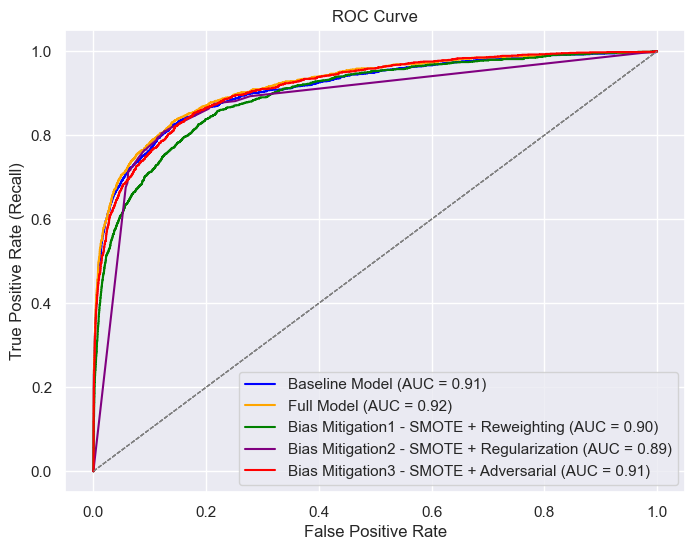

In [66]:
fig, ax = plt.subplots(figsize=(8, 6))

auc_baseline, _ = plot_roc_auc(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model',
    color='blue',
    ax=ax
)

auc_full, _ = plot_roc_auc(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model',
    color='orange',
    ax=ax
)

auc_bm1, _ = plot_roc_auc(
    y_true=y_test_bm1,
    y_scores=y_proba_bm1,
    label='Bias Mitigation1 - SMOTE + Reweighting',
    color='green',
    ax=ax
)

auc_bm2, _ = plot_roc_auc(
    y_true=y_test_bm2,
    y_scores=y_proba_bm2,
    label='Bias Mitigation2 - SMOTE + Regularization',
    color='purple',
    ax=ax
)

auc_bm3, _ = plot_roc_auc(
    y_true=y_test_bm3,
    y_scores=y_proba_bm3,
    label='Bias Mitigation3 - SMOTE + Adversarial',
    color='red',
    ax=ax
)

ax.legend()
plt.show()


Baseline Model (No Sensitive Features)
Best threshold based on F1 score: 0.327
Precision: 0.720, Recall: 0.590, F1: 0.648

Full Model (With Sensitive Features)
Best threshold based on F1 score: 0.356
Precision: 0.743, Recall: 0.579, F1: 0.651

Bias Mitigation1 - SMOTE + Reweighting
Best threshold based on F1 score: 0.821
Precision: 0.664, Recall: 0.515, F1: 0.580

Bias Mitigation2 - SMOTE + Regularization
Best threshold based on F1 score: 0.973
Precision: 0.508, Recall: 0.712, F1: 0.593

Bias Mitigation3 - SMOTE + Adversarial
Best threshold based on F1 score: 0.847
Precision: 0.653, Recall: 0.606, F1: 0.629


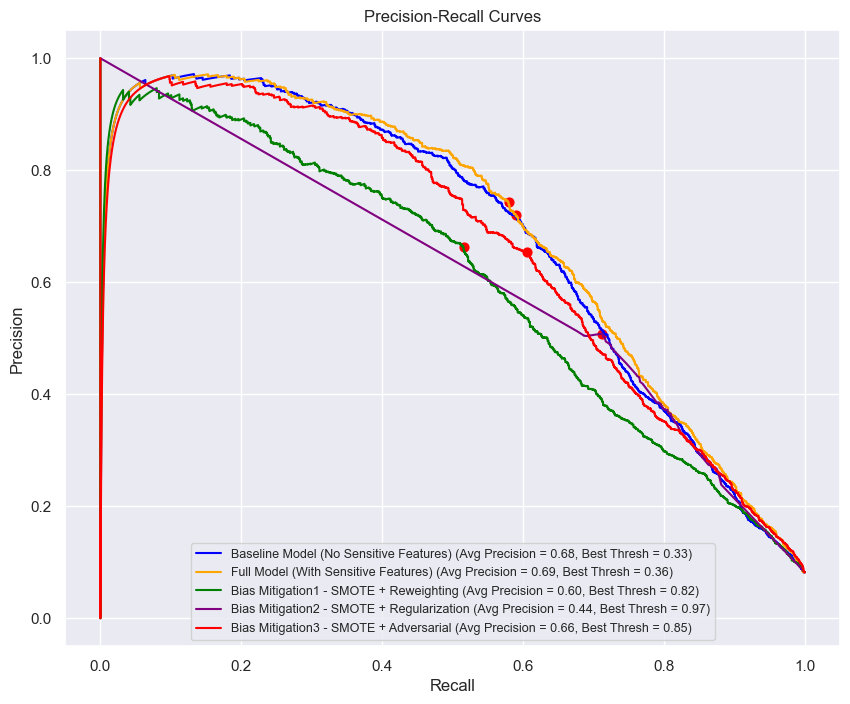

In [67]:
fig, ax = plt.subplots(figsize=(10, 8))


best_thresh_baseline, y_pred_baseline, auc_baseline, best_f1_baseline, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model (No Sensitive Features)',
    color='blue',
    ax=ax
)

best_thresh_full, y_pred_full, auc_full, best_f1_full, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model (With Sensitive Features)',
    color='orange',
    ax=ax
)


best_thresh_bm1, y_pred_bm1, auc_bm1, best_f1_bm1, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm1,
    y_scores=y_proba_bm1,
    label='Bias Mitigation1 - SMOTE + Reweighting',
    color='green',
    ax=ax
)


best_thresh_bm2, y_pred_bm2, auc_bm2, best_f1_bm2, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm2,
    y_scores=y_proba_bm2,
    label='Bias Mitigation2 - SMOTE + Regularization',
    color='purple',
    ax=ax
)


best_thresh_bm3, y_pred_bm3, auc_bm3, best_f1_bm3, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm3,
    y_scores=y_proba_bm3,
    label='Bias Mitigation3 - SMOTE + Adversarial',
    color='red',
    ax=ax
)


ax.legend(fontsize=9)
plt.title('Precision-Recall Curves')
plt.grid(True)
plt.show()


Baseline Model (No Sensitive Features)
              precision    recall  f1-score   support

           0      0.964     0.979     0.972     17339
           1      0.720     0.590     0.648      1550

    accuracy                          0.947     18889
   macro avg      0.842     0.785     0.810     18889
weighted avg      0.944     0.947     0.945     18889


AUC: 0.912

Full Model (With Sensitive Features)
              precision    recall  f1-score   support

           0      0.963     0.982     0.973     17339
           1      0.743     0.579     0.651      1550

    accuracy                          0.949     18889
   macro avg      0.853     0.781     0.812     18889
weighted avg      0.945     0.949     0.946     18889

AUC: 0.920

Bias Mitigation1 - SMOTE + Reweighting
              precision    recall  f1-score   support

           0      0.958     0.977     0.967     17339
           1      0.664     0.515     0.580      1550

    accuracy                          0.93

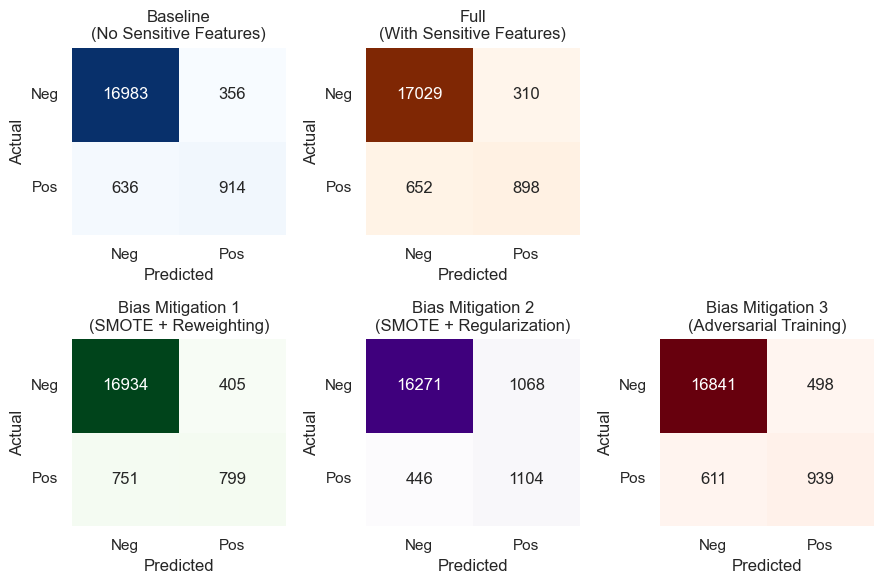

In [68]:


print("Baseline Model (No Sensitive Features)")
print(classification_report(y_test_baseline, y_pred_baseline, digits=3))
print(f"\nAUC: {auc_baseline:.3f}")

print("\nFull Model (With Sensitive Features)")
print(classification_report(y_test_full, y_pred_full, digits=3))
print(f"AUC: {auc_full:.3f}")

print("\nBias Mitigation1 - SMOTE + Reweighting")
print(classification_report(y_test_bm1, y_pred_bm1, digits=3))
print(f"AUC: {auc_bm1:.3f}")

print("\nBias Mitigation2 - SMOTE + Regularization")
print(classification_report(y_test_bm2, y_pred_bm2, digits=3))
print(f"AUC: {auc_bm2:.3f}")

print("\nBias Mitigation3 - SMOTE + Adversarial")
print(classification_report(y_test_bm3, y_pred_bm3, digits=3))
print(f"AUC: {auc_bm3:.3f}")


cm_baseline = confusion_matrix(y_test_baseline, y_pred_baseline)
cm_full = confusion_matrix(y_test_full, y_pred_full)
cm_bm1 = confusion_matrix(y_test_bm1, y_pred_bm1)
cm_bm2 = confusion_matrix(y_test_bm2, y_pred_bm2)
cm_bm3 = confusion_matrix(y_test_bm3, y_pred_bm3)

fig, axs = plt.subplots(2, 3, figsize=(9, 6))
axs = axs.flatten()

# Baseline
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axs[0])
axs[0].set_title('Baseline\n(No Sensitive Features)')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].set_xticklabels(['Neg', 'Pos'])
axs[0].set_yticklabels(['Neg', 'Pos'], rotation=0)

# Full
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axs[1])
axs[1].set_title('Full\n(With Sensitive Features)')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].set_xticklabels(['Neg', 'Pos'])
axs[1].set_yticklabels(['Neg', 'Pos'], rotation=0)

axs[2].axis('off')

# BM1
sns.heatmap(cm_bm1, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axs[3])
axs[3].set_title('Bias Mitigation 1\n(SMOTE + Reweighting)')
axs[3].set_xlabel('Predicted')
axs[3].set_ylabel('Actual')
axs[3].set_xticklabels(['Neg', 'Pos'])
axs[3].set_yticklabels(['Neg', 'Pos'], rotation=0)

# BM2
sns.heatmap(cm_bm2, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axs[4])
axs[4].set_title('Bias Mitigation 2\n(SMOTE + Regularization)')
axs[4].set_xlabel('Predicted')
axs[4].set_ylabel('Actual')
axs[4].set_xticklabels(['Neg', 'Pos'])
axs[4].set_yticklabels(['Neg', 'Pos'], rotation=0)

# BM3
sns.heatmap(cm_bm3, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axs[5])
axs[5].set_title('Bias Mitigation 3\n(Adversarial Training)')
axs[5].set_xlabel('Predicted')
axs[5].set_ylabel('Actual')
axs[5].set_xticklabels(['Neg', 'Pos'])
axs[5].set_yticklabels(['Neg', 'Pos'], rotation=0)

plt.tight_layout()
plt.show()


#### Fairness Diagnosis

In [69]:

df_test_full = create_df_test(df, X_test_full, y_test_full, y_pred_full, y_proba_full)
df_test_baseline = create_df_test(df, X_test_baseline, y_test_baseline, y_pred_baseline, y_proba_baseline)
df_test_bm1 = create_df_test(df, X_test_bm1, y_test_bm1, y_pred_bm1, y_proba_bm1)
df_test_bm2 = create_df_test(df, X_test_bm2, y_test_bm2, y_pred_bm2, y_proba_bm2)
df_test_bm3 = create_df_test(df, X_test_bm3, y_test_bm3, y_pred_bm3, y_proba_bm3)

gender_report_full = get_group_metrics(df_test_full, 'gender_group')
age_report_full = get_group_metrics(df_test_full, 'age_group')
race_report_full = get_group_metrics(df_test_full, 'race_group')

gender_report_baseline = get_group_metrics(df_test_baseline, 'gender_group')
age_report_baseline = get_group_metrics(df_test_baseline, 'age_group')
race_report_baseline = get_group_metrics(df_test_baseline, 'race_group')

gender_report_bm1 = get_group_metrics(df_test_bm1, 'gender_group')
age_report_bm1 = get_group_metrics(df_test_bm1, 'age_group')
race_report_bm1 = get_group_metrics(df_test_bm1, 'race_group')

gender_report_bm2 = get_group_metrics(df_test_bm2, 'gender_group')
age_report_bm2 = get_group_metrics(df_test_bm2, 'age_group')
race_report_bm2 = get_group_metrics(df_test_bm2, 'race_group')

gender_report_bm3 = get_group_metrics(df_test_bm3, 'gender_group')
age_report_bm3 = get_group_metrics(df_test_bm3, 'age_group')
race_report_bm3 = get_group_metrics(df_test_bm3, 'race_group')


gender_report_full['model'] = 'Full'
age_report_full['model'] = 'Full'
race_report_full['model'] = 'Full'

gender_report_baseline['model'] = 'Baseline'
age_report_baseline['model'] = 'Baseline'
race_report_baseline['model'] = 'Baseline'

gender_report_bm1['model'] = 'bm1'
age_report_bm1['model'] = 'bm1'
race_report_bm1['model'] = 'bm1'

gender_report_bm2['model'] = 'bm2'
age_report_bm2['model'] = 'bm2'
race_report_bm2['model'] = 'bm2'

gender_report_bm3['model'] = 'bm3'
age_report_bm3['model'] = 'bm3'
race_report_bm3['model'] = 'bm3'

gender_comparison = pd.concat([gender_report_full, gender_report_baseline, gender_report_bm1, gender_report_bm2, gender_report_bm3])
age_comparison = pd.concat([age_report_full, age_report_baseline, age_report_bm1, age_report_bm2, age_report_bm3])
race_comparison = pd.concat([race_report_full, race_report_baseline, race_report_bm1, race_report_bm2, race_report_bm3])

gender_comparison
age_comparison
race_comparison

,group,support,precision,recall (TPR),f1_score,FPR,PPR,model
0,WHITE,867.0,0.763608,0.566321,0.650331,0.013879,0.054404,Full
1,OTHER,61.0,0.773585,0.672131,0.719298,0.015852,0.064792,Full
2,UNKNOWN,329.0,0.742647,0.613982,0.672213,0.037076,0.122688,Full
3,BLACK,141.0,0.666667,0.553191,0.604651,0.020051,0.056088,Full
4,HISPANIC/LATINO,52.0,0.767442,0.634615,0.694737,0.015798,0.062774,Full
5,ASIAN,53.0,0.761905,0.603774,0.673684,0.019342,0.073684,Full
6,EUROPEAN,29.0,0.478261,0.379310,0.423077,0.024691,0.044660,Full
7,RUSSIAN,18.0,0.666667,0.555556,0.606061,0.031056,0.083799,Full
0,WHITE,867.0,0.718271,0.594002,0.650253,0.018444,0.060665,Baseline
1,OTHER,61.0,0.736842,0.688525,0.711864,0.019815,0.069682,Baseline


#### Equal Opportunity  

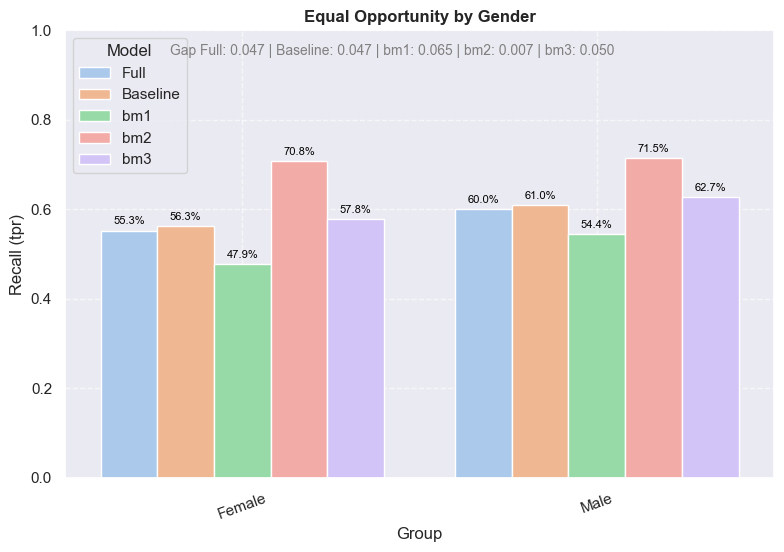

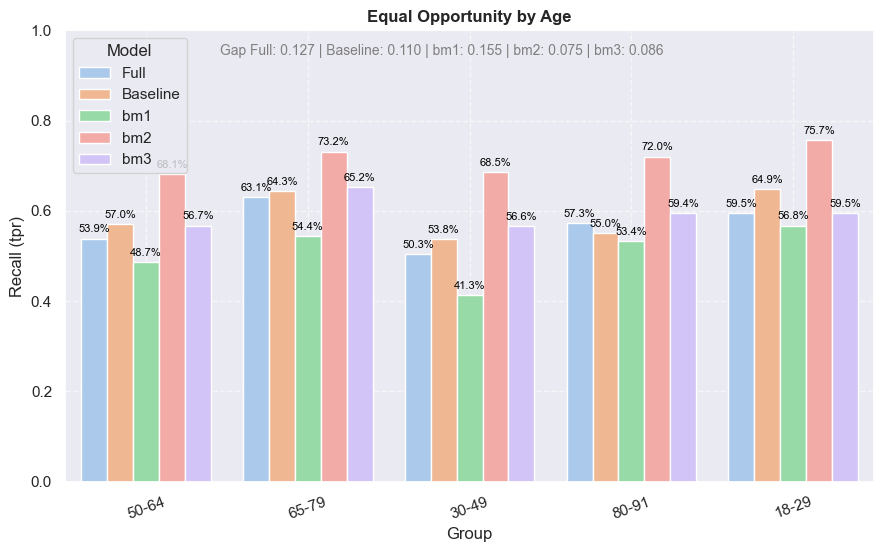

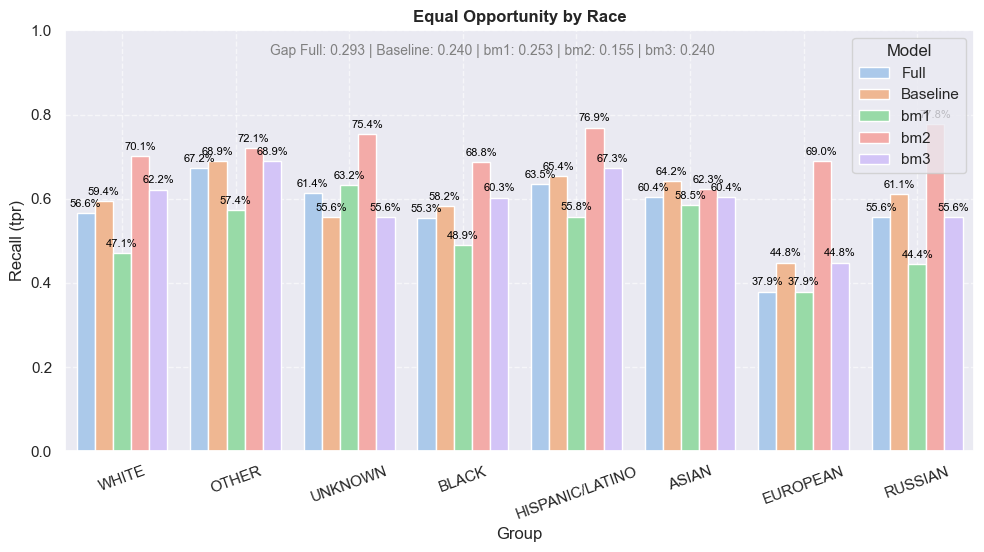

In [70]:
gender_eo_dict = plot_equal_opportunity(gender_comparison, metric='recall (TPR)', title='Equal Opportunity by Gender', figsize=(8, 6))
age_eo_dict = plot_equal_opportunity(age_comparison, metric='recall (TPR)', title='Equal Opportunity by Age', figsize=(9, 6))
race_eo_dict = plot_equal_opportunity(race_comparison, metric='recall (TPR)', title='Equal Opportunity by Race', figsize=(10, 6))

#### Statistical Parity

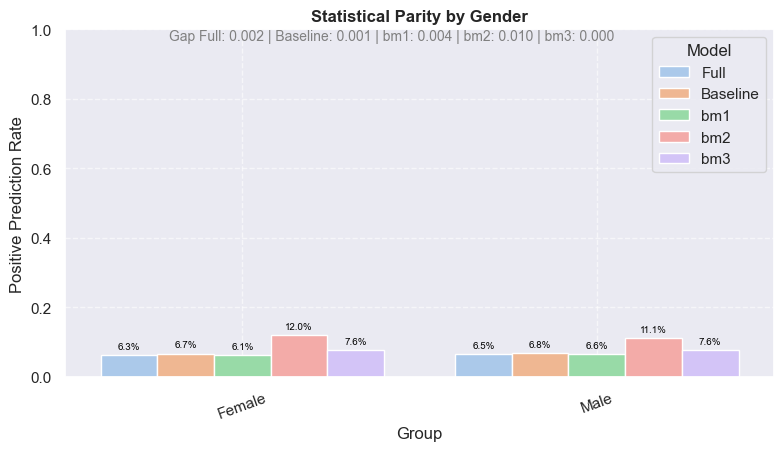

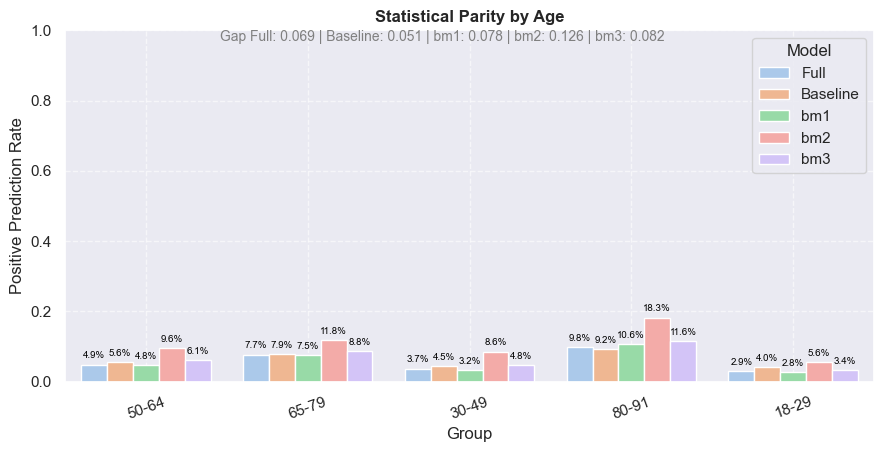

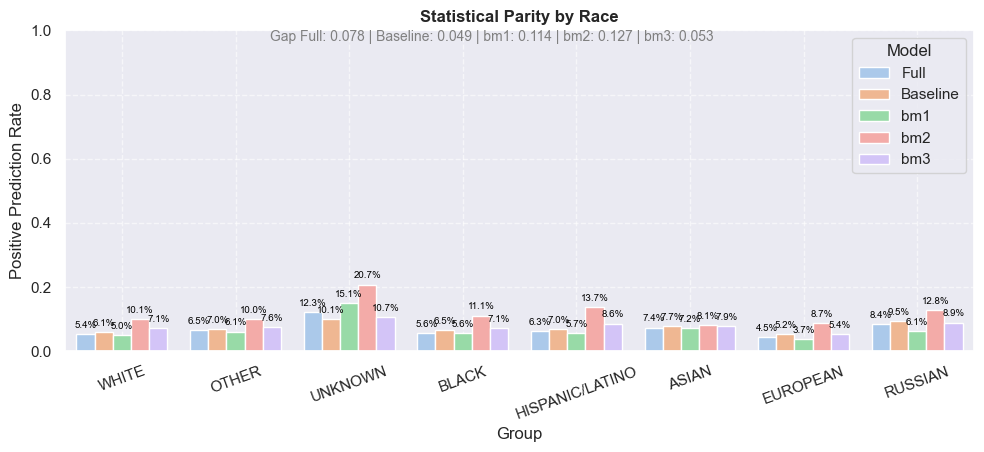

In [71]:
gender_ppr_dict = plot_statistical_parity(df=gender_comparison, title='Statistical Parity by Gender', figsize=(8, 5))
age_ppr_dict = plot_statistical_parity(df=age_comparison, title='Statistical Parity by Age', figsize=(9, 5))
race_ppr_dict = plot_statistical_parity(df=race_comparison, title='Statistical Parity by Race', figsize=(10, 5))

#### Equalized Odds

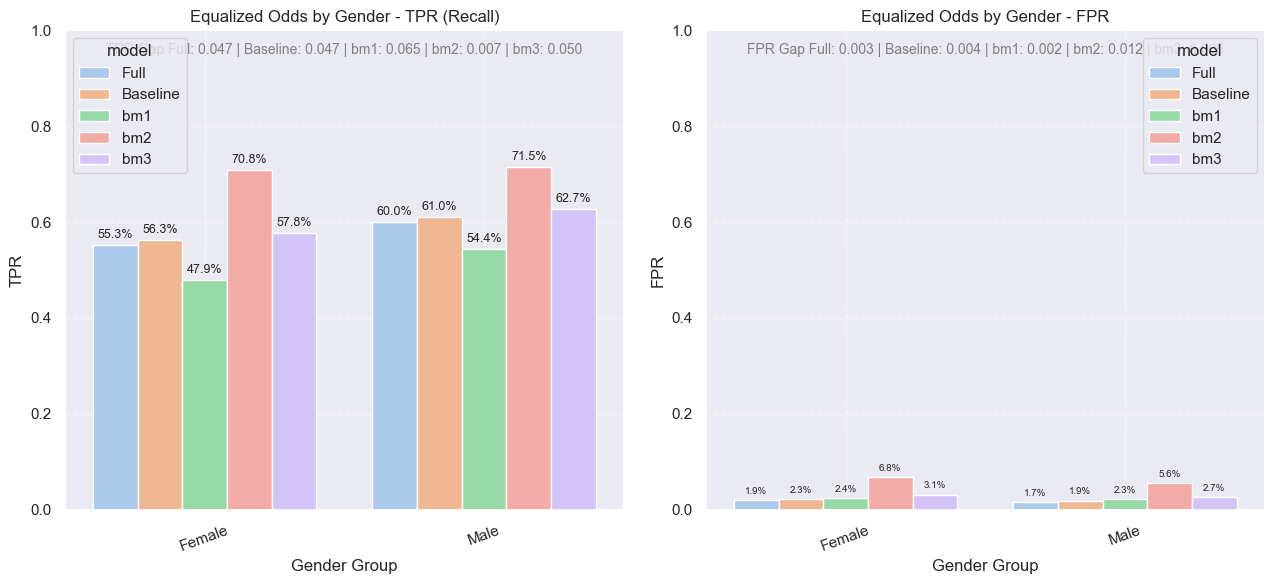

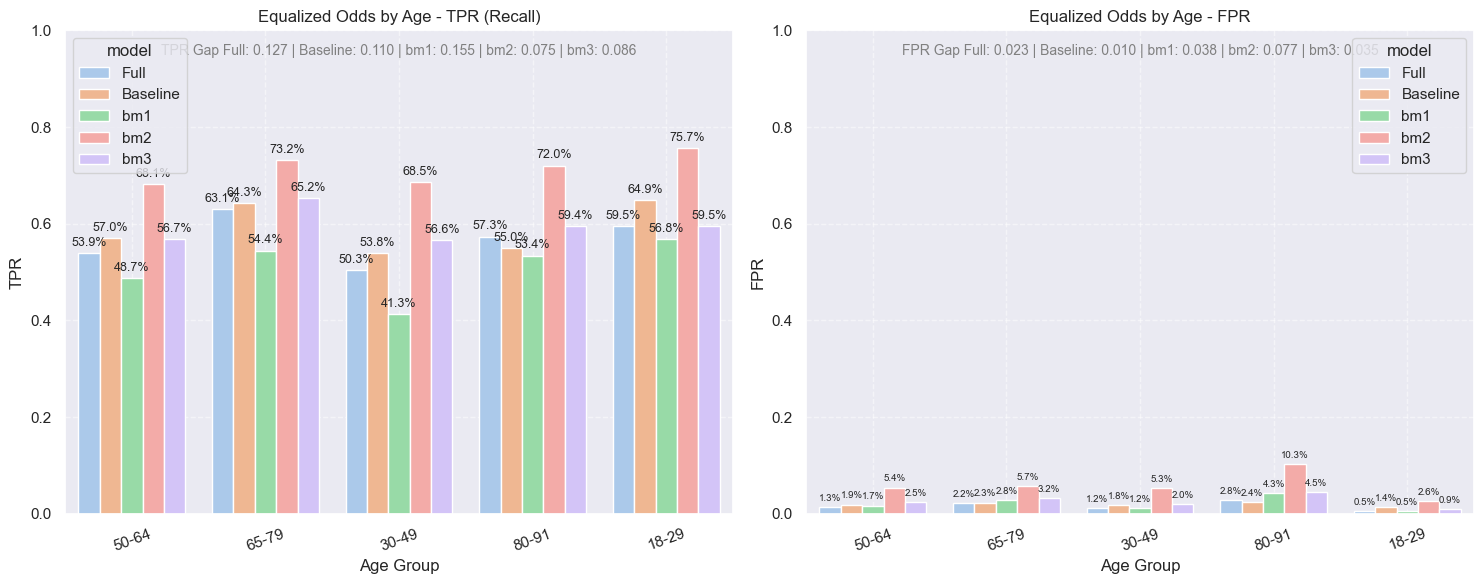

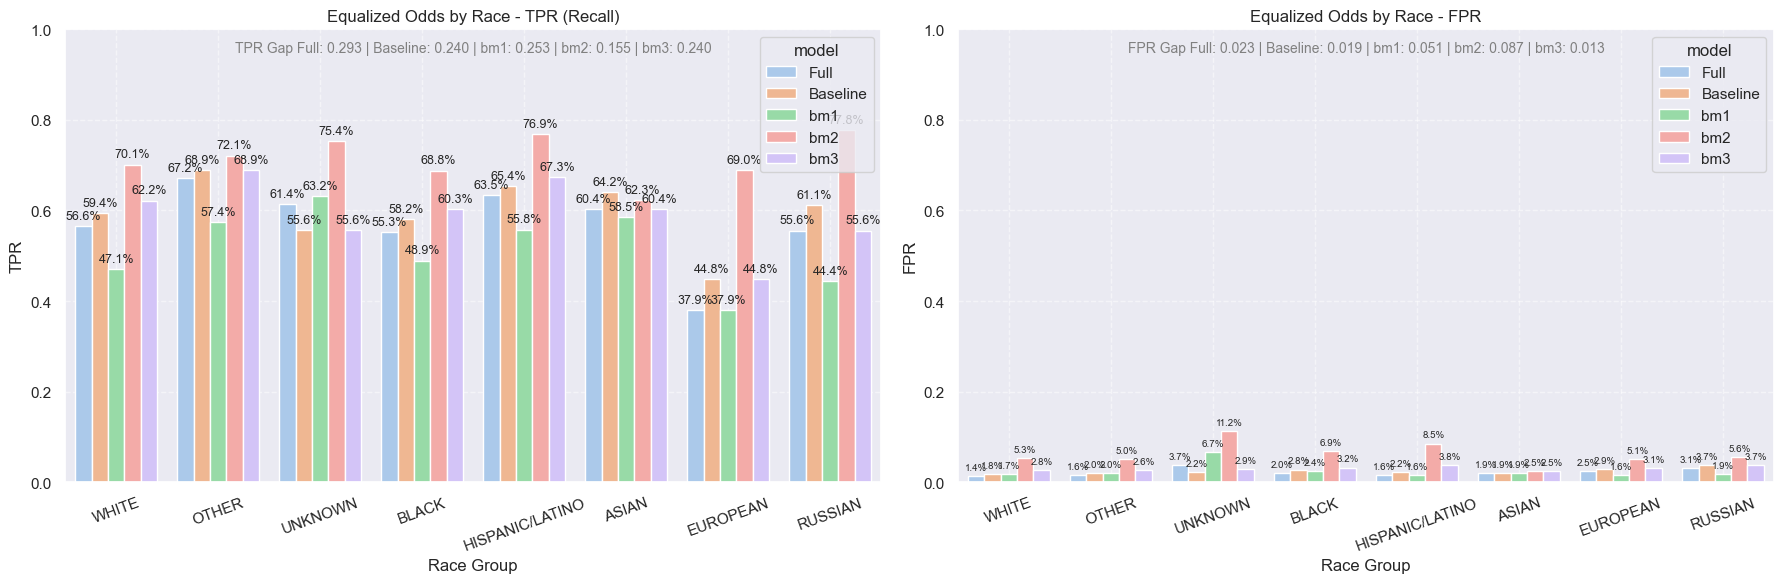

In [72]:
gender_tpr_dict, gender_fpr_dict = plot_equalized_odds(gender_comparison, group_col_name='Gender Group', title_prefix='Equalized Odds by Gender', figsize=(13, 6))
age_tpr_dict, age_fpr_dict = plot_equalized_odds(age_comparison, group_col_name='Age Group', title_prefix='Equalized Odds by Age', figsize=(15, 6))
race_tpr_dict, race_fpr_dict = plot_equalized_odds(race_comparison, group_col_name='Race Group', title_prefix='Equalized Odds by Race', figsize=(18, 6))

#### Calibration

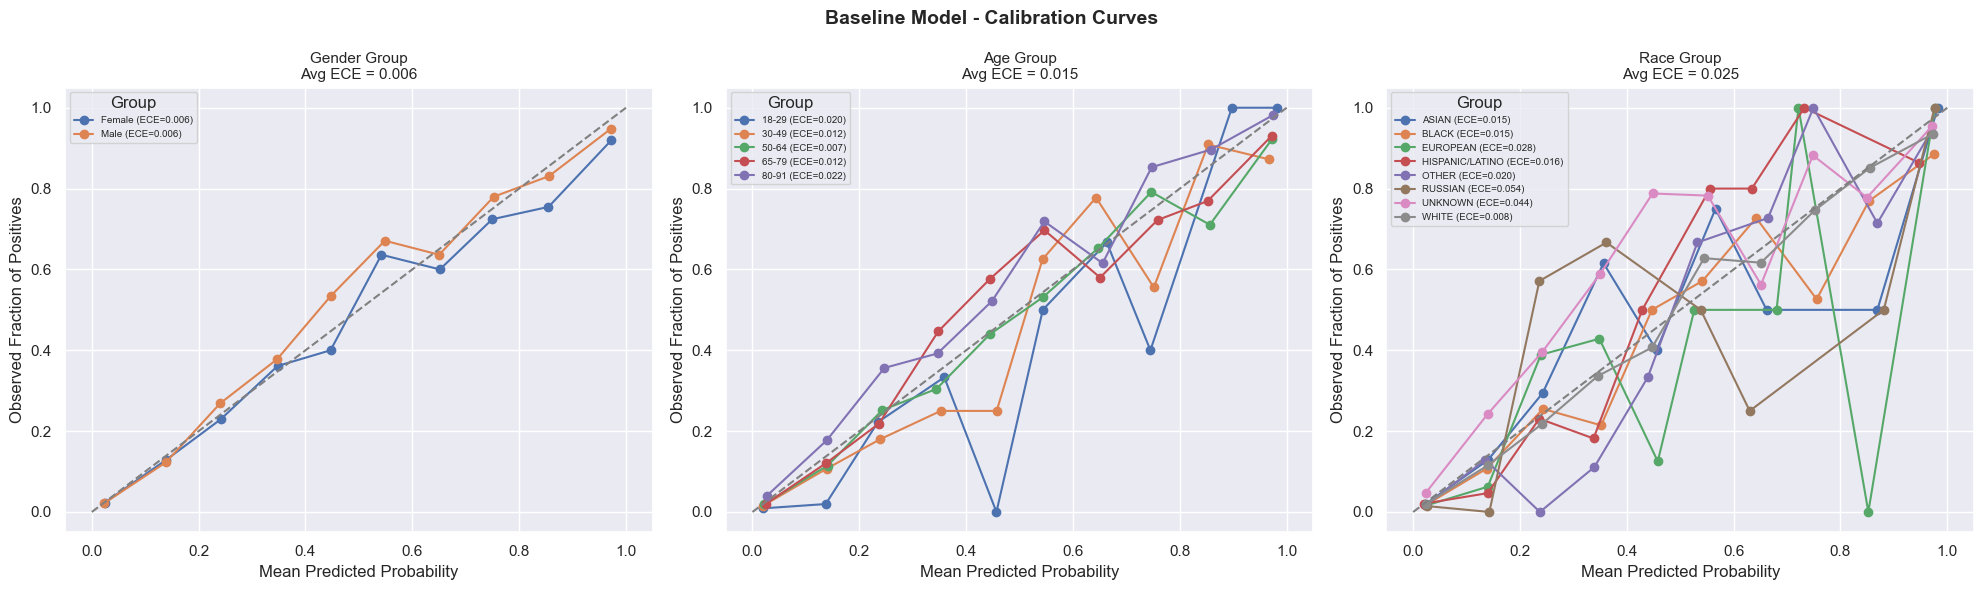

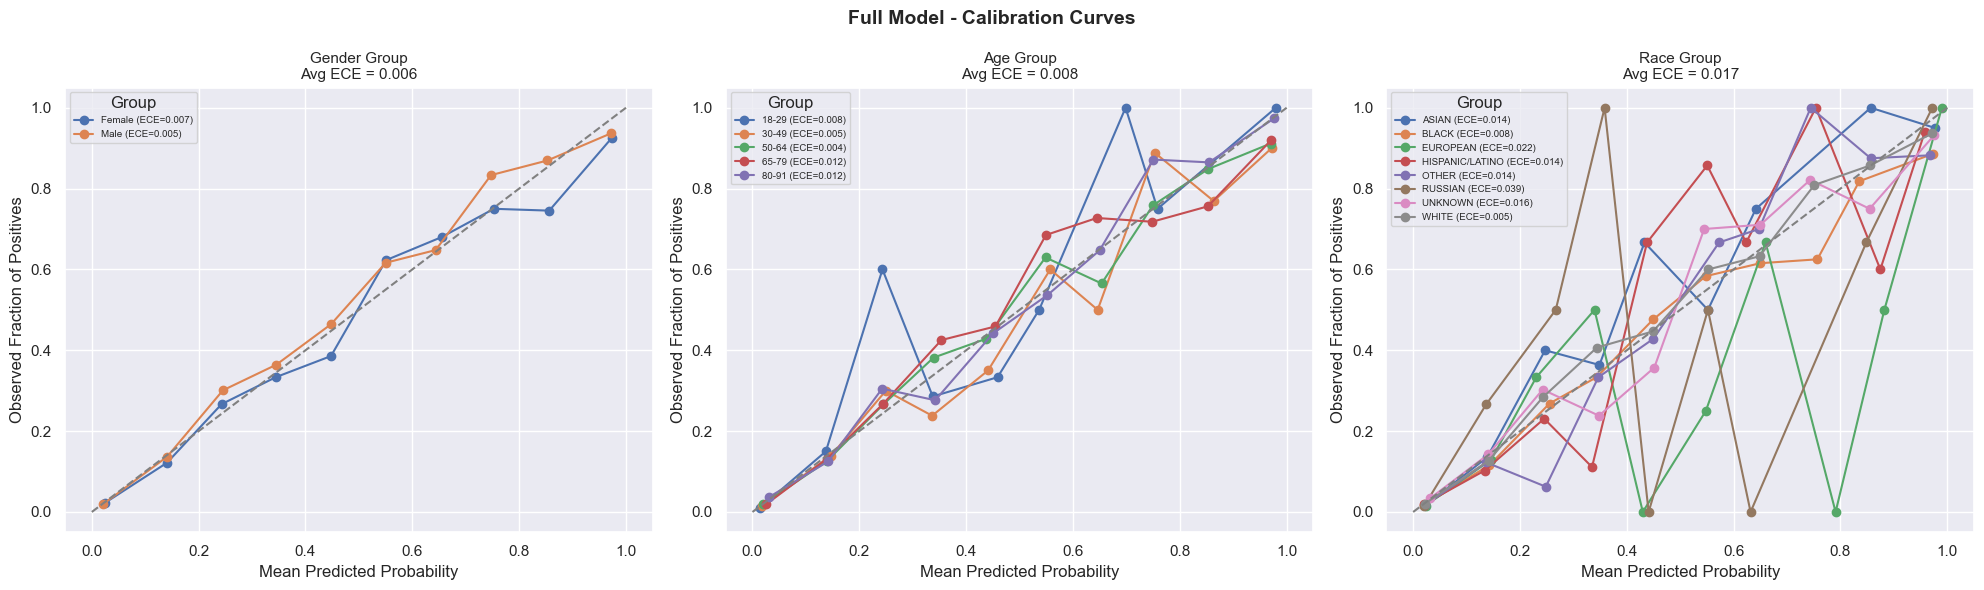

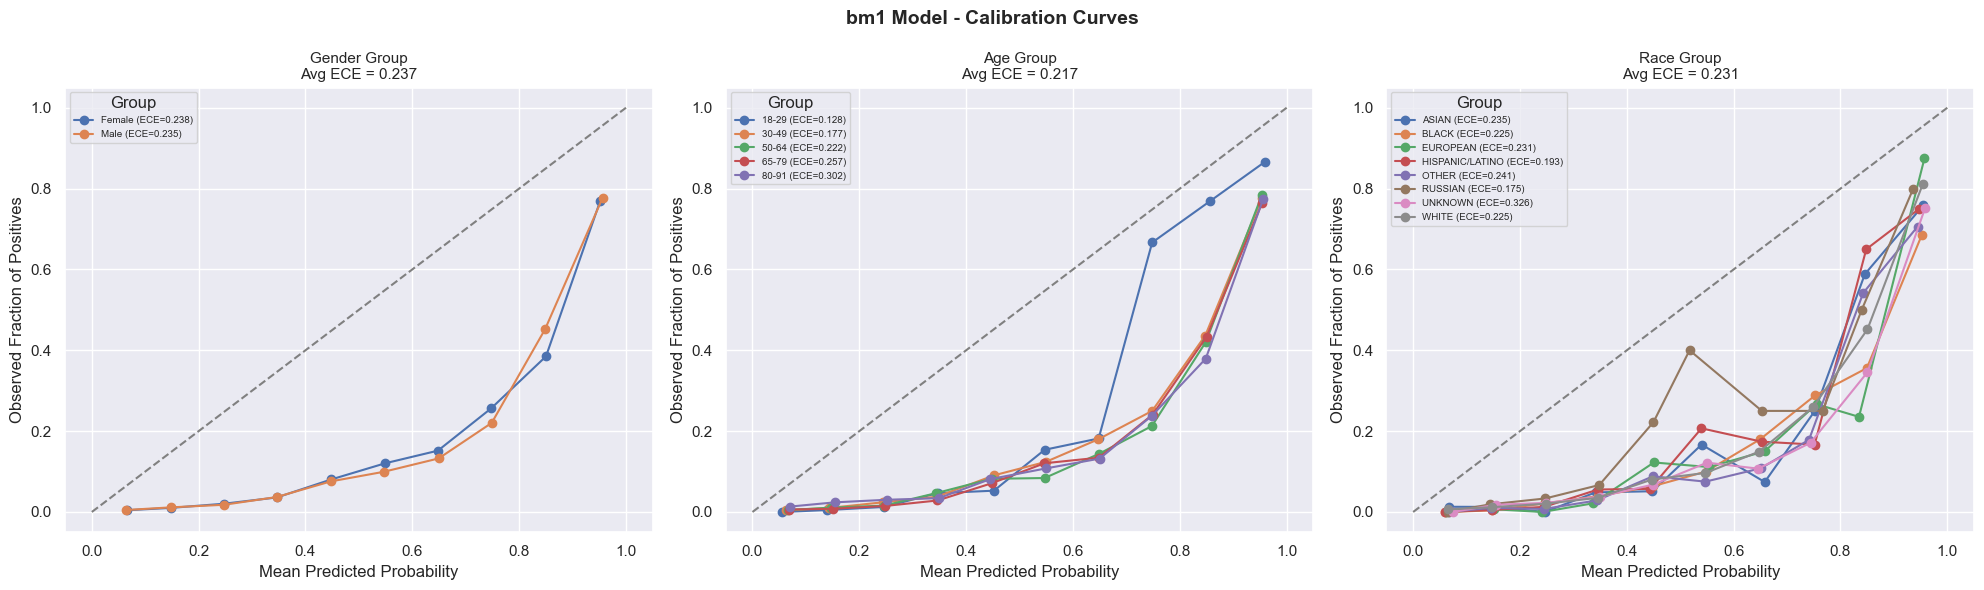

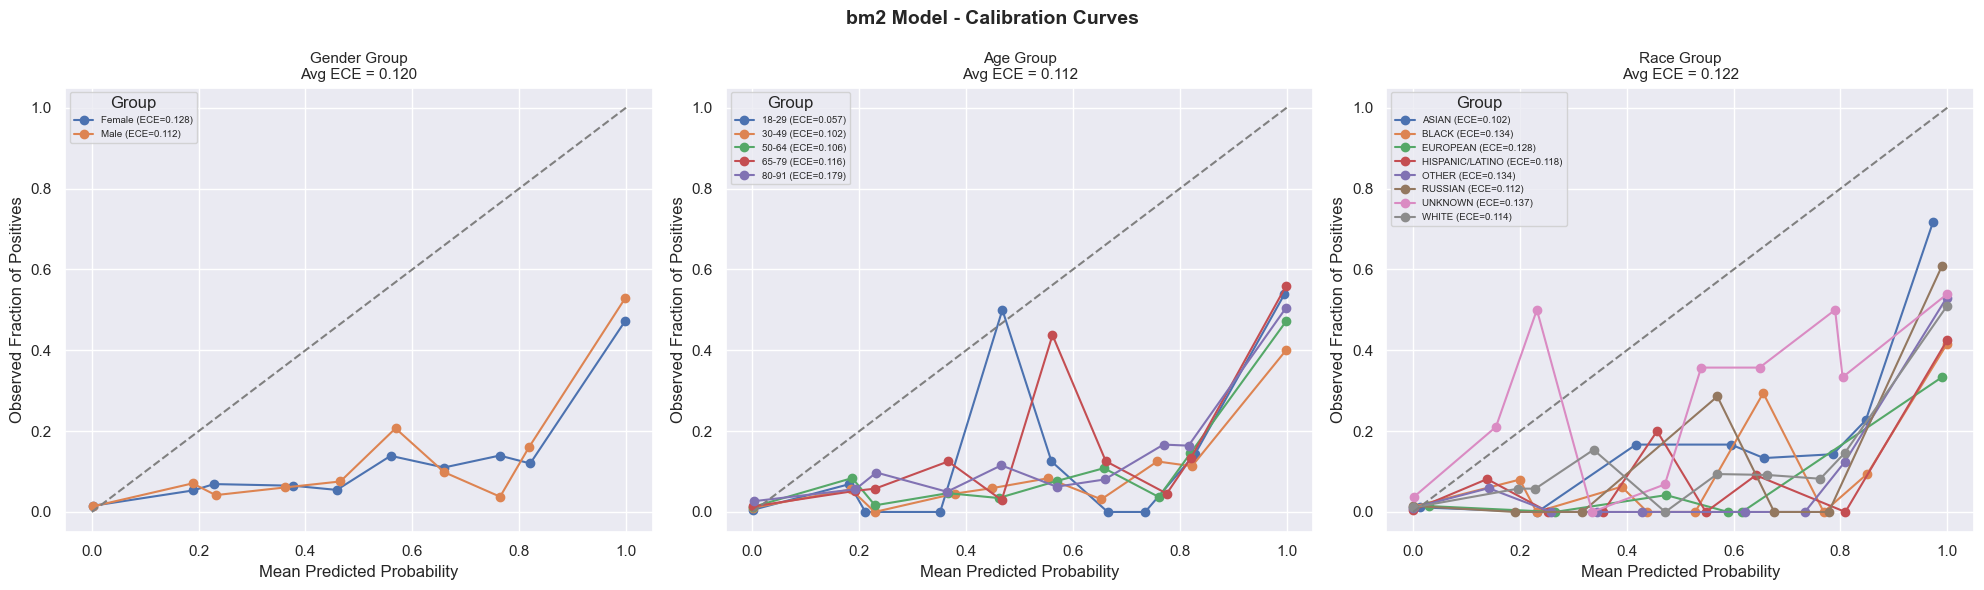

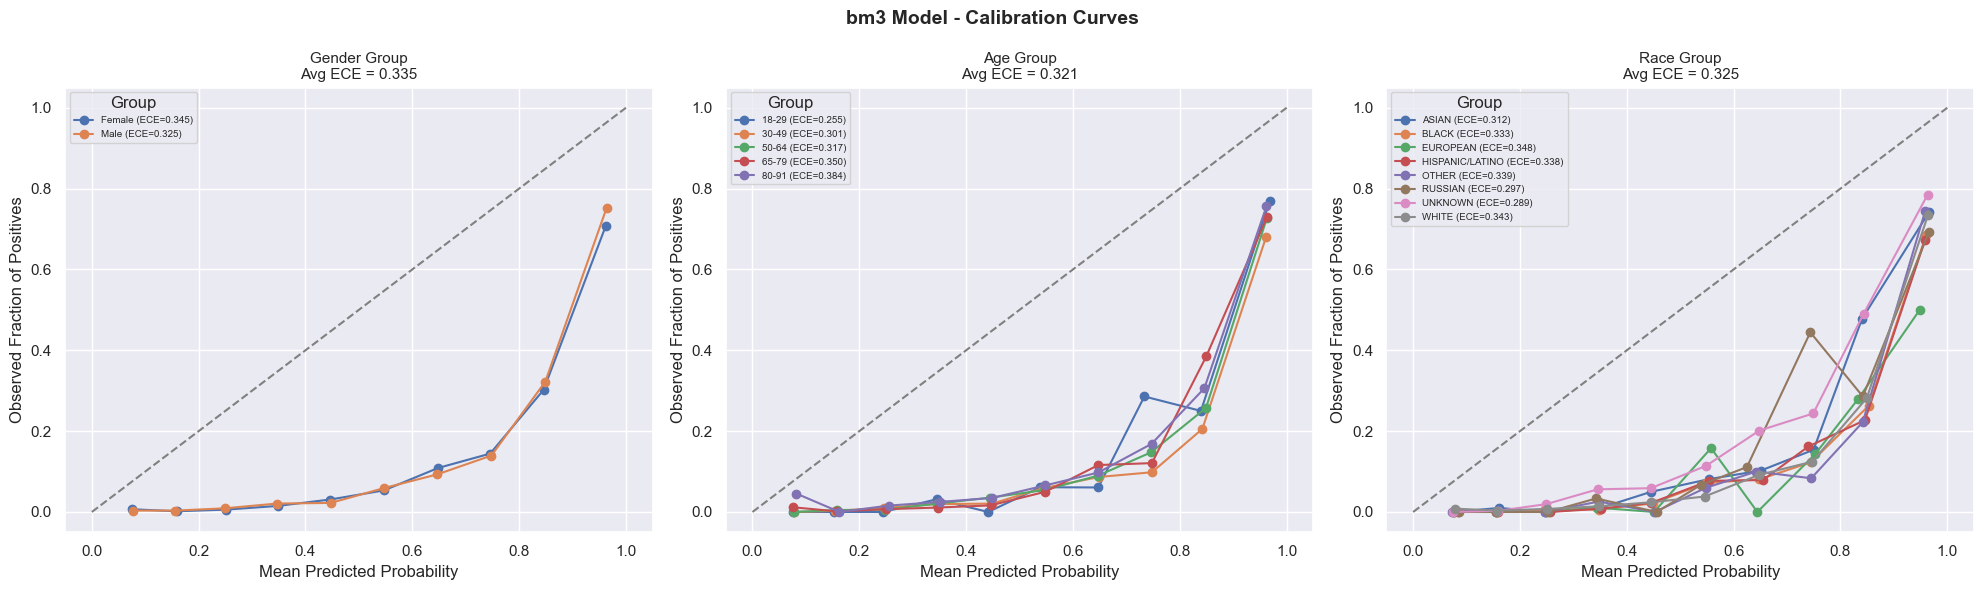

In [73]:
df_list = [df_test_baseline, df_test_full, df_test_bm1, df_test_bm2, df_test_bm3]
model_label = ['Baseline', 'Full', 'bm1', 'bm2', 'bm3']
avg_subgroup_ece = {}
for df_l, model_l in zip(df_list, model_label):
    avg_subgroup_ece[model_l] = plot_calibration_ece(df=df_l, model_label = model_l, figsize=(20, 6))


#### 	Fairness-Performance Tradeoff Analysis

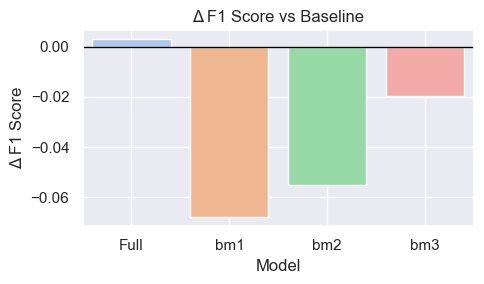

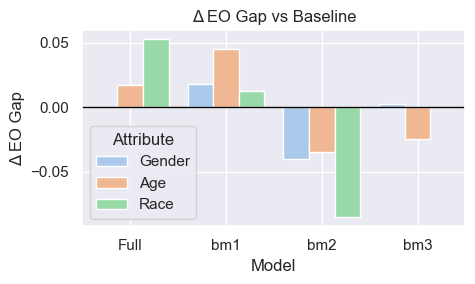

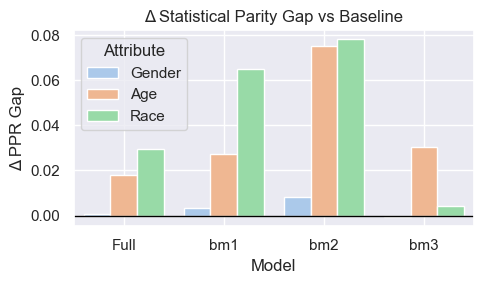

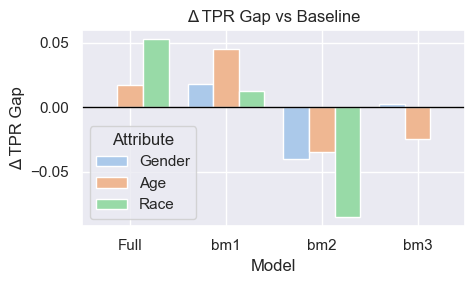

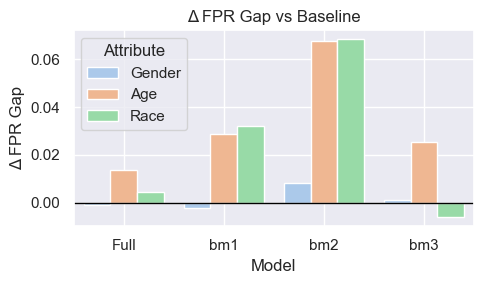

In [74]:
models = ['Full', 'bm1', 'bm2', 'bm3']

f1_deltas = [best_f1_full - best_f1_baseline,
             best_f1_bm1 - best_f1_baseline,
             best_f1_bm2 - best_f1_baseline,
             best_f1_bm3 - best_f1_baseline]

gender_eo_deltas = [gender_eo_dict[model] - gender_eo_dict['Baseline'] for model in models]
age_eo_deltas = [age_eo_dict[model] - age_eo_dict['Baseline'] for model in models]
race_eo_deltas = [race_eo_dict[model] - race_eo_dict['Baseline'] for model in models]

gender_ppr_deltas = [gender_ppr_dict[model] - gender_ppr_dict['Baseline'] for model in models]
age_ppr_deltas = [age_ppr_dict[model] - age_ppr_dict['Baseline'] for model in models]
race_ppr_deltas = [race_ppr_dict[model] - race_ppr_dict['Baseline'] for model in models]

gender_tpr_deltas = [gender_tpr_dict[model] - gender_tpr_dict['Baseline'] for model in models]
age_tpr_deltas    = [age_tpr_dict[model] - age_tpr_dict['Baseline'] for model in models]
race_tpr_deltas   = [race_tpr_dict[model] - race_tpr_dict['Baseline'] for model in models]

gender_fpr_deltas = [gender_fpr_dict[model] - gender_fpr_dict['Baseline'] for model in models]
age_fpr_deltas    = [age_fpr_dict[model] - age_fpr_dict['Baseline'] for model in models]
race_fpr_deltas   = [race_fpr_dict[model] - race_fpr_dict['Baseline'] for model in models]


df_f1 = pd.DataFrame({
    'Model': models,
    'Δ F1 Score': f1_deltas
})

df_eo = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ EO Gap': gender_eo_deltas + age_eo_deltas + race_eo_deltas
})


df_ppr = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ PPR Gap': gender_ppr_deltas + age_ppr_deltas + race_ppr_deltas
})


df_tpr = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ TPR Gap': gender_tpr_deltas + age_tpr_deltas + race_tpr_deltas
})


df_fpr = pd.DataFrame({
    'Model': models * 3,
    'Attribute': ['Gender'] * 4 + ['Age'] * 4 + ['Race'] * 4,
    'Δ FPR Gap': gender_fpr_deltas + age_fpr_deltas + race_fpr_deltas
})

sns.set(style="darkgrid")

plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ F1 Score', hue='Model', data=df_f1, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ F1 Score vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ EO Gap', hue='Attribute', data=df_eo, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ EO Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ PPR Gap', hue='Attribute', data=df_ppr, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ Statistical Parity Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ TPR Gap', hue='Attribute', data=df_tpr, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ TPR Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(5, 3))
sns.barplot(x='Model', y='Δ FPR Gap', hue='Attribute', data=df_fpr, palette='pastel')
plt.axhline(0, color='black', linewidth=1)
plt.title('Δ FPR Gap vs Baseline')
plt.grid(True)
plt.tight_layout()
plt.show()

In [75]:
models = ['Full', 'Baseline', 'bm1', 'bm2', 'bm3']
gender_fairness_df = pd.DataFrame({
    'Model': models,
    'Attribute': ['Gender'] * len(models),
    'PPR Gap': [gender_ppr_dict[model] for model in models], # statistical parity gap
    'TPR Gap': [gender_tpr_dict[model] for model in models], # equal opportunity gap
    'FPR Gap': [gender_fpr_dict[model] for model in models], # equalized odds gap (omit tpr)
    'ECE': [avg_subgroup_ece[model]['gender_group'] for model in models],
    'F1 Score': [best_f1_full, best_f1_baseline, best_f1_bm1, best_f1_bm2, best_f1_bm3]
})

# Normalize the fairness gaps to create an index bounded between 0 and 1
gender_fairness_df['Fairness Total'] = gender_fairness_df[['PPR Gap', 'TPR Gap', 'FPR Gap', 'ECE']].sum(axis=1)
gender_fairness_df['Fairness Index'] = 1 / (1 + gender_fairness_df['Fairness Total'])
gender_fairness_df


age_fairness_df = pd.DataFrame({
    'Model': models,
    'Attribute': ['Age'] * len(models),
    'PPR Gap': [age_ppr_dict[model] for model in models], # statistical parity gap
    'TPR Gap': [age_tpr_dict[model] for model in models], # equal opportunity gap
    'FPR Gap': [age_fpr_dict[model] for model in models], # equalized odds gap (omit tpr)
    'ECE': [avg_subgroup_ece[model]['age_group'] for model in models],
    'F1 Score': [best_f1_full, best_f1_baseline, best_f1_bm1, best_f1_bm2, best_f1_bm3]
})

# Normalize the fairness gaps to create an index bounded between 0 and 1
age_fairness_df['Fairness Total'] = age_fairness_df[['PPR Gap', 'TPR Gap', 'FPR Gap', 'ECE']].sum(axis=1)
age_fairness_df['Fairness Index'] = 1 / (1 + age_fairness_df['Fairness Total'])
age_fairness_df


race_fairness_df = pd.DataFrame({
    'Model': models,
    'Attribute': ['Race'] * len(models),
    'PPR Gap': [race_ppr_dict[model] for model in models], # statistical parity gap
    'TPR Gap': [race_tpr_dict[model] for model in models], # equal opportunity gap
    'FPR Gap': [race_fpr_dict[model] for model in models], # equalized odds gap (omit tpr)
    'ECE': [avg_subgroup_ece[model]['race_group'] for model in models],
    'F1 Score': [best_f1_full, best_f1_baseline, best_f1_bm1, best_f1_bm2, best_f1_bm3]
})

# Normalize the fairness gaps to create an index bounded between 0 and 1
race_fairness_df['Fairness Total'] = race_fairness_df[['PPR Gap', 'TPR Gap', 'FPR Gap', 'ECE']].sum(axis=1)
race_fairness_df['Fairness Index'] = 1 / (1 + race_fairness_df['Fairness Total'])
race_fairness_df

fairness_df = pd.concat([gender_fairness_df, age_fairness_df, race_fairness_df], ignore_index=True)
fairness_df

,Model,Attribute,PPR Gap,TPR Gap,FPR Gap,ECE,F1 Score,Fairness Total,Fairness Index
0,Full,Gender,0.002025,0.047407,0.002758,0.005881,0.651197,0.058072,0.945115
1,Baseline,Gender,0.001214,0.047323,0.003645,0.005669,0.648227,0.057850,0.945313
2,bm1,Gender,0.004442,0.065481,0.001648,0.236548,0.580247,0.308119,0.764456
3,bm2,Gender,0.009521,0.007280,0.011872,0.120258,0.593229,0.148931,0.870374
4,bm3,Gender,0.000424,0.049651,0.004723,0.335213,0.628724,0.390011,0.719419
5,Full,Age,0.069162,0.127134,0.023290,0.008167,0.651197,0.227753,0.814496
6,Baseline,Age,0.051307,0.110187,0.009766,0.014557,0.648227,0.185817,0.843300
7,bm1,Age,0.078408,0.154980,0.038489,0.217359,0.580247,0.489236,0.671485
8,bm2,Age,0.126432,0.075410,0.077145,0.112027,0.593229,0.391013,0.718900
9,bm3,Age,0.081816,0.085819,0.035181,0.321273,0.628724,0.524088,0.656130


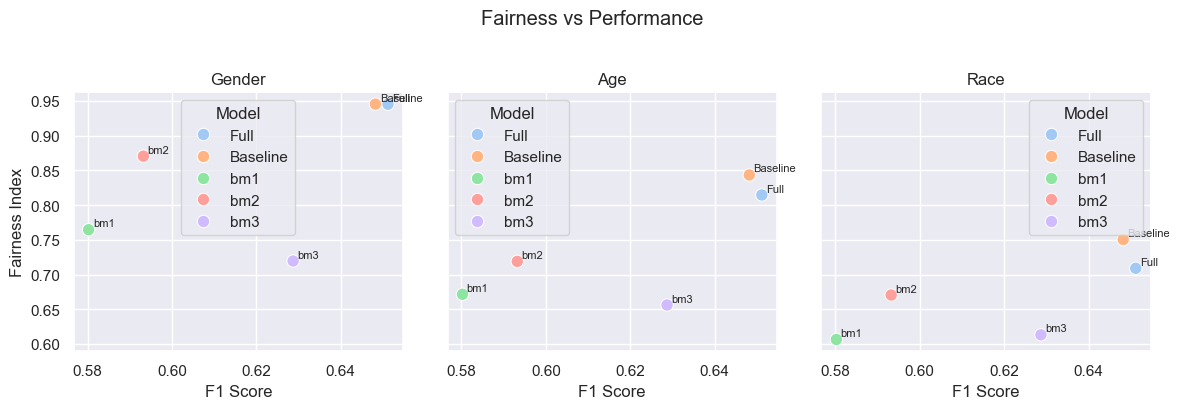

In [76]:
sns.set(style="darkgrid")
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

attributes = ['Gender', 'Age', 'Race']
for ax, attr in zip(axs, attributes):
    subset = fairness_df[fairness_df['Attribute'] == attr]
    
    sns.scatterplot(data=subset, x='F1 Score', y='Fairness Index', hue='Model', palette='pastel', s=80, ax=ax)
    fig.suptitle('Fairness vs Performance', y=1.02)
    for idx, row in subset.iterrows():
        ax.text(row['F1 Score'] + 0.001, row['Fairness Index'] + 0.005, row['Model'], fontsize=8)

    ax.set_title(f'{attr}')
    ax.set_xlabel('F1 Score')
    ax.set_ylabel('Fairness Index')
    ax.grid(True)
    ax.legend().set_title('Model')

plt.tight_layout()
plt.show()
